In [1]:
# path to user functions
import sys  
sys.path.append('../Src/')

from platform import python_version

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import importlib 
from sklearn.preprocessing import OrdinalEncoder

# import user functions
import UserUtilityFunctions as uf
import UserStatisticalFunctions as usf
import UserVisualization as uv
import UserImputeFunctions as uif

# set seaborn theme
sns.set_theme()

# initializing variables
REMOVE = '** REMOVE ** CAT ML'
RANDOM_STATE = 1776

# print versions
print("Numpy Version: " + np.__version__)
print("Pandas Version: " + pd.__version__)
print("Seaborn Version: " + sns.__version__)
print("Matplotlib Version: " + plt.matplotlib.__version__)
print("Python Version: " + python_version())

# adjust pandas display options to max
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# adjust pandas display options to ensure full display of content
pd.set_option('display.max_colwidth', None)

Numpy Version: 1.26.4
Pandas Version: 2.2.3
Seaborn Version: 0.13.2
Matplotlib Version: 3.9.2
Python Version: 3.9.20


####  Mann-Whitney U Test

#####  Mann-Whitney U test
- The Mann-Whitney U test is a non-parametric statistical test used to determine whether there is a significant difference between the distributions of two independent samples. It is often used as an alternative to the t-test when the assumption of normality is not met.
    - Key Assumptions
        - The two samples are independent.
        - The data is ordinal, interval, or ratio scale.
        - The distributions of the two groups are similar in shape if testing medians.
    - Interpretation
        - If the p-value is less than your significance level (e.g., 0.05), you reject the null hypothesis and conclude that there is a statistically significant difference between the two groups.
        - If the p-value is greater than the significance level, you fail to reject the null hypothesis, indicating insufficient evidence to suggest a difference in distributions.

### Import Data

In [2]:
# import data
df = pd.read_pickle("../Data/5Heart_ML_Orig.pkl")
df_label = pd.read_pickle("../Data/5Label_ML.pkl")
df_can = pd.read_pickle("../Data/5CAN_ML.pkl")
df_don = pd.read_pickle("../Data/5DON_ML.pkl")
df_both = pd.read_pickle("../Data/5BOTH_ML.pkl")
df_nominal = pd.read_pickle("../Data/5Nominal_ML.pkl")
df_ordinal = pd.read_pickle("../Data/5Ordinal_ML.pkl")
df_numeric = pd.read_pickle("../Data/5Numeric_ML.pkl")
df_new = pd.read_pickle("../Data/5New_ML.pkl")
df_drop = pd.read_pickle("../Data/5Drop_ML.pkl")
df_dict = pd.read_pickle("../Data/5Dictionary_ML.pkl")
df_object = pd.read_pickle("../Data/5Object_ML.pkl")
df_unknown = pd.read_pickle("../Data/5Unknown_ML.pkl")
df_date = pd.read_pickle("../Data/5Date_ML.pkl")

# checking for duplicated column name
df.columns[df.columns.duplicated()]

Index([], dtype='object')

In [3]:
print(f"Heart Dataset Rows: {df.shape[0]:,} & Columns: {df.shape[1]:,}")
print(f"Label Features: {df_label.shape[0]:,}")
print(f"Candidate Features: {df_can.shape[0]:,}")
print(f"Donor Features: {df_don.shape[0]:,}")
print(f"Both Features: {df_both.shape[0]:,}")
print(f"Nominal Features: {df_nominal.shape[0]:,}")
print(f"Ordinal Features: {df_ordinal.shape[0]:,}")
print(f"Numeric Features: {df_numeric.shape[0]:,}")
print(f"New Features: {df_new.shape[0]:,}")
print(f"Drop Features: {df_drop.shape[0]:,}")
print(f"Dictionary Features: {df_object.shape[0]:,}")
print(f"Object Features: {df_object.shape[0]:,}")
print(f"Unknown Features: {df_unknown.shape[0]:,}")
print(f"Date Features: {df_date.shape[0]:,}")

Heart Dataset Rows: 26,600 & Columns: 234
Label Features: 2
Candidate Features: 128
Donor Features: 87
Both Features: 19
Nominal Features: 166
Ordinal Features: 12
Numeric Features: 57
New Features: 22
Drop Features: 22
Dictionary Features: 0
Object Features: 0
Unknown Features: 0
Date Features: 0


### Examine Features

In [4]:
df[df_label.column.to_list()].head()

,TransplantSurvivalDay,LengthOfStay
0,329.0,76.0
1,2592.0,10.0
2,2913.0,21.0
3,1225.0,32.0
4,2785.0,26.0


In [5]:
# remove unwanted labels
removeCols = df_label.column[~df_label.column.isin(['TransplantSurvivalDay'])].to_list()
removeCols.extend(df_new.column.to_list())

# remove features
df, df_dict, df_label, df_can, df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date = uf.HouseKeeping(df, removeCols, df_dict, df_label, df_can,\
                                                                df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date, txt=REMOVE, display=True)

Data Dictionary Updated.
Remove 1 row(s) from df_label DataFrame.
Remove 10 row(s) from df_can DataFrame.
Remove 2 row(s) from df_don DataFrame.
Remove 12 row(s) from df_both DataFrame.
Remove 0 row(s) from df_ordinal DataFrame.
Remove 0 row(s) from df_nominal DataFrame.
Remove 23 row(s) from df_numeric DataFrame.
Remove 0 row(s) from df_drop DataFrame.
Remove 0 row(s) from df_object DataFrame.
Remove 0 row(s) from df_unknown DataFrame.
Remove 0 row(s) from df_date DataFrame.

Removed Features: ['Age_Addition', 'Age_Difference', 'BMI_Addition', 'BMI_Difference', 'Creatinine_Addition_CAN', 'Creatinine_Difference_CAN', 'Creatinine_Mean_CAN', 'HeightCm_Addition', 'HeightCm_Difference', 'Hemodynamics_Addition_Mean_CAN', 'Hemodynamics_Interaction_Mean_CAN', 'Hemodynamics_Mean_CO_RT_CAN', 'Hemodynamics_Mean_PA_DIA_RT_CAN', 'Hemodynamics_Mean_PA_MN_RT_CAN', 'Hemodynamics_Mean_PCW_RT_CAN', 'Hemodynamics_Mean_SYS_RT_CAN', 'LengthOfStay', 'Level_SGOT_Addition_DON', 'Level_SGOT_Difference_DON', '

### Determine Candidate Survival for 600 Days

In [6]:
# remove rows where TransplantSurvivalDay is NaN
df = df.dropna(subset=['TransplantSurvivalDay'])
# print
print(f"Heart Dataset Rows: {df.shape[0]:,} & Columns: {df.shape[1]:,}")

Heart Dataset Rows: 26,600 & Columns: 211


In [7]:
# initialize
removeCols = ['TransplantSurvivalDay']

# create new feature
df['Survival'] = df.TransplantSurvivalDay >= 600

# remove features
df, df_dict, df_label, df_can, df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date = uf.HouseKeeping(df, removeCols, df_dict, df_label, df_can,\
                                                                df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date, txt=REMOVE, display=True)

Data Dictionary Updated.
Remove 1 row(s) from df_label DataFrame.
Remove 0 row(s) from df_can DataFrame.
Remove 0 row(s) from df_don DataFrame.
Remove 0 row(s) from df_both DataFrame.
Remove 0 row(s) from df_ordinal DataFrame.
Remove 0 row(s) from df_nominal DataFrame.
Remove 1 row(s) from df_numeric DataFrame.
Remove 0 row(s) from df_drop DataFrame.
Remove 0 row(s) from df_object DataFrame.
Remove 0 row(s) from df_unknown DataFrame.
Remove 0 row(s) from df_date DataFrame.

Removed Features: ['TransplantSurvivalDay']

Total Row(s) & Column(s) Before Removing Column(s): 26,600 & columns: 212
Total Row(s) & Column(s) After Removing Column(s): 26,600 & columns: 211


In [8]:
# sanity check
uf.datatypeDF(df, display=True)

Total Data feature count:  211

Boolean feature count: 1
Category feature count: 76
Numeric feature count: 33
Object feature count: 101
Other feature count: 0

Total feature count:  211


In [9]:
# display NaNs
uf.percentageNull(df)

,percentage,NaNCount
HemodynamicsRegistration_PCW_CAN,3.357143,893
HemodynamicsTransplant_PCW_CAN,3.357143,893
HemodynamicsTransplant_CO_CAN,2.000000,532
HemodynamicsRegistration_CO_CAN,2.000000,532
HemodynamicsRegistration_PA_MN_CAN,1.616541,430
HemodynamicsTransplant_PA_MN_CAN,1.616541,430
HemodynamicsRegistration_PA_DIA_CAN,1.484962,395
HemodynamicsTransplant_PA_DIA_CAN,1.484962,395
HemodynamicsRegistration_SYS_CAN,1.458647,388
HemodynamicsTransplant_SYS_CAN,1.458647,388


In [10]:
# check label
df.Survival.value_counts()

Survival
True     18099
False     8501
Name: count, dtype: int64

In [11]:
# remove unused categories
df = uf.removeCatZeroCount(df).copy()

In [12]:
df_nominal.shape

(166, 1)

### Engineer / Remove Features

##### Test of Independence for Categorical Variables
- Null Hypothesis (H0): The two variables are not related.
- Alternative Hypothesis (H1): The two variables are related.
- A low p-value (typically < 0.05) indicates a significant relationship between the variables.
- This is the Chi-Square test statistic. It measures the discrepancy between the observed and expected frequencies under the assumption that the variables are independent.
    - A larger `chi2` value indicates a greater difference between observed and expected counts, suggesting that the variables are more likely to be associated.
    - A small p_value (typically < 0.05) suggests that you can reject the null hypothesis and conclude that there is a significant association between the two variables.

##### Cramer's V values can be interpreted as:
- Cramer's V is a measure of association between two nominal (categorical) variables, based on the Chi-Square statistic and varies from `0` (corresponding to no association between the variables) to `1` (complete association) and can reach 1 only when each variable is completely determined by the other.
    - 0.00 to 0.10: Negligible association
    - 0.10 to 0.30: Weak association
    - 0.30 to 0.50: Moderate association
    - 0.50 to 0.70: Strong association
    - 0.70 to 1.00: Very strong association

### Discretization

#### Numeric

In [13]:
print(sorted(df_numeric.column.to_list()))

['Age_CAN', 'Age_DON', 'BMI_CAN', 'BMI_DON', 'BloodPH_DON', 'BloodUreaNitrogenLevel_DON', 'CreatinineRegistration_CAN', 'CreatinineTransplant_CAN', 'Creatinine_DON', 'DistanceFromDonorHospitaltoTXCenter', 'HeightCm_CAN', 'HeightCm_DON', 'Hematocrit_DON', 'HemodynamicsRegistration_CO_CAN', 'HemodynamicsRegistration_PA_DIA_CAN', 'HemodynamicsRegistration_PA_MN_CAN', 'HemodynamicsRegistration_PCW_CAN', 'HemodynamicsRegistration_SYS_CAN', 'HemodynamicsTransplant_CO_CAN', 'HemodynamicsTransplant_PA_DIA_CAN', 'HemodynamicsTransplant_PA_MN_CAN', 'HemodynamicsTransplant_PCW_CAN', 'HemodynamicsTransplant_SYS_CAN', 'IschemicTimeHour_DON', 'LV_EjectionFractionPercent_DON', 'Level_SGOT_ALT_DON', 'Level_SGOT_AST_DON', 'OrganRecovery_PCO2_DON', 'TerminalTotalBilirubin_DON', 'TotalBilirubinTransplant_CAN', 'TotalDayWaitList_CAN', 'WeightKg_CAN', 'WeightKg_DON']


##### Age

In [14]:
features = uf.getFeatureList(df, 'Age_')

           count       mean        std   min   25%   50%   75%   max
Age_CAN  26600.0  53.414361  12.897743  18.0  46.0  56.0  63.0  79.0
Age_DON  26600.0  32.144023  10.959943   8.0  23.0  31.0  40.0  72.0

:::: NaN Count:
Age_CAN    0
Age_DON    0


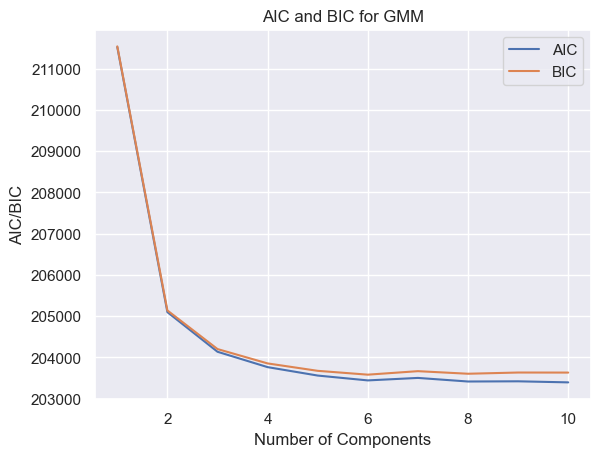

In [15]:
uif.GaussianMixtureBinning(df, ['Age_CAN'], RANDOM_STATE)

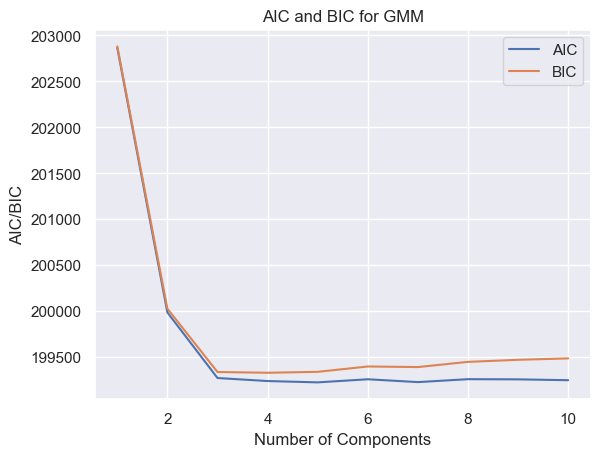

In [16]:
uif.GaussianMixtureBinning(df, ['Age_DON'], RANDOM_STATE)

In [17]:
df[features].describe().T

,count,mean,std,min,25%,50%,75%,max
Age_CAN,26600.0,53.414361,12.897743,18.0,46.0,56.0,63.0,79.0
Age_DON,26600.0,32.144023,10.959943,8.0,23.0,31.0,40.0,72.0


In [18]:
# use quartile bin
df['Age_CAT_CAN'] = pd.qcut(df['Age_CAN'], q=4, labels=['Age (Min-46)', 'Age(47-56)', 'Age(57-63)', 'Age(65-Max)'])
df['Age_CAT_DON'] = pd.qcut(df['Age_DON'], q=4, labels=['Age (Min-23)', 'Age(24-31)', 'Age(32-40)', 'Age(41-Max)'])

# category datatype
df['Age_CAT_CAN'] = df['Age_CAT_CAN'].astype('category')
df['Age_CAT_DON'] = df['Age_CAT_DON'].astype('category')

# update DataFrame
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['Age_CAT_CAN', 'Age_CAT_DON'])
df_don = uf.insertIntoDataFrame(df_don, ['Age_CAT_DON'])
df_can = uf.insertIntoDataFrame(df_can, ['Age_CAT_CAN'])

# add to list
removeCols = features

In [19]:
uf.categoryContingencySurvival(df, 'Age_CAT_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
Age (Min-46),2120.0,4592.0,6712.0,31.585221,68.414779
Age(47-56),2006.0,4615.0,6621.0,30.297538,69.702462
Age(57-63),2220.0,4569.0,6789.0,32.699956,67.300044
Age(65-Max),2155.0,4323.0,6478.0,33.266440,66.733560
Column Total,8501.0,18099.0,26600.0,31.958647,68.041353


In [20]:
uf.categoryContingencySurvival(df, 'Age_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
Age (Min-23),1956.0,5033.0,6989.0,27.986836,72.013164
Age(24-31),2243.0,4677.0,6920.0,32.413295,67.586705
Age(32-40),2263.0,4099.0,6362.0,35.570575,64.429425
Age(41-Max),2039.0,4290.0,6329.0,32.216780,67.783220
Column Total,8501.0,18099.0,26600.0,31.958647,68.041353


##### [BMI](https://www.cdc.gov/bmi/adult-calculator/bmi-categories.html)
- The standard BMI ranges for adults are:
    - Underweight: BMI less than 18.5 kg/m²
    - Normal weight: BMI 18.5 to 24.9 kg/m²
    - Overweight: BMI 25 to 29.9 kg/m²
    - Obesity: BMI 30 kg/m² or greater
    - BMI = Weight (kg) / Height (m)²

In [21]:
def categorizeBMI(value):
    """
    Define the function for mapping
    """
    if value < 18.5:
        return "Under Weight"
    elif 18.5 <= value <= 24.9:
        return "Normal Weight"        
    elif 24.9 <= value <= 29.9:
        return "Over Weight"
    elif value >= 29.9:
        return "Obesity"
    else:
        return "Unknown"

##### HeightCm

In [22]:
features = uf.getFeatureList(df, 'HeightCm')

                count        mean       std    min    25%    50%    75%    max
HeightCm_CAN  26600.0  173.649444  10.02993  124.0  167.6  175.0  180.3  213.4
HeightCm_DON  26600.0  173.887699   9.57433  115.0  167.6  175.0  180.3  213.0

:::: NaN Count:
HeightCm_CAN    0
HeightCm_DON    0


In [23]:
# use quartile bin
df['HeightCm_CAT_CAN'] = pd.qcut(df['HeightCm_CAN'], q=4, labels=['HeightCm (Min-168)', 'HeightCm(169-175)', 'HeightCm(176-181)', 'HeightCm(182-Max)'])
df['HeightCm_CAT_DON'] = pd.qcut(df['HeightCm_DON'], q=4, labels=['HeightCm (Min-168)', 'HeightCm(169-175)', 'HeightCm(176-181)', 'HeightCm(182-Max)'])

# category datatype
df['HeightCm_CAT_CAN'] = df['HeightCm_CAT_CAN'].astype('category')
df['HeightCm_CAT_DON'] = df['HeightCm_CAT_DON'].astype('category')

# update DataFrame
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['HeightCm_CAT_CAN', 'HeightCm_CAT_DON'])
df_don = uf.insertIntoDataFrame(df_don, ['HeightCm_CAT_DON'])
df_can = uf.insertIntoDataFrame(df_can, ['HeightCm_CAT_CAN'])

# add to list
removeCols.extend(features)

In [24]:
uf.categoryContingencySurvival(df, 'HeightCm_CAT_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
HeightCm (Min-168),2681.0,5477.0,8158.0,32.863447,67.136553
HeightCm(169-175),1628.0,3590.0,5218.0,31.199693,68.800307
HeightCm(176-181),2184.0,4856.0,7040.0,31.022727,68.977273
HeightCm(182-Max),2008.0,4176.0,6184.0,32.470893,67.529107
Column Total,8501.0,18099.0,26600.0,31.958647,68.041353


In [25]:
uf.categoryContingencySurvival(df, 'HeightCm_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
HeightCm (Min-168),2101.0,4805.0,6906.0,30.422821,69.577179
HeightCm(169-175),2444.0,4888.0,7332.0,33.333333,66.666667
HeightCm(176-181),1882.0,4078.0,5960.0,31.577181,68.422819
HeightCm(182-Max),2074.0,4328.0,6402.0,32.396126,67.603874
Column Total,8501.0,18099.0,26600.0,31.958647,68.041353


##### WeightKg

In [26]:
features = uf.getFeatureList(df, 'WeightKg')

                count       mean        std   min   25%   50%   75%    max
WeightKg_CAN  26600.0  83.199955  18.071337  29.9  70.3  82.5  95.3  159.1
WeightKg_DON  26600.0  83.449485  19.515971  23.2  70.0  80.6  94.0  198.0

:::: NaN Count:
WeightKg_CAN    0
WeightKg_DON    0


In [27]:
# new features
df['WeightKg_CAT_CAN'] = pd.qcut(df['WeightKg_CAN'], q=4, labels=['WeightKg (Min-70)', 'WeightKg(71-83)', 'WeightKg(84-96)', 'WeightKg(97-Max)'])
df['WeightKg_CAT_DON'] = pd.qcut(df['WeightKg_DON'], q=4, labels=['WeightKg (Min-70)', 'WeightKg(70-81)', 'WeightKg(82-94)', 'WeightKg(95-Max)'])

# category datatype
df['WeightKg_CAT_CAN'] = df['WeightKg_CAT_CAN'].astype('category')
df['WeightKg_CAT_DON'] = df['WeightKg_CAT_DON'].astype('category')

# update DataFrame
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['WeightKg_CAT_CAN', 'WeightKg_CAT_DON'])
df_don = uf.insertIntoDataFrame(df_don, ['WeightKg_CAT_DON'])
df_can = uf.insertIntoDataFrame(df_can, ['WeightKg_CAT_CAN'])

# add to list
removeCols.extend(features)

In [28]:
uf.categoryContingencySurvival(df, 'WeightKg_CAT_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
WeightKg (Min-70),2017.0,4713.0,6730.0,29.970282,70.029718
WeightKg(71-83),2068.0,4517.0,6585.0,31.404708,68.595292
WeightKg(84-96),2175.0,4509.0,6684.0,32.540395,67.459605
WeightKg(97-Max),2241.0,4360.0,6601.0,33.949402,66.050598
Column Total,8501.0,18099.0,26600.0,31.958647,68.041353


In [29]:
uf.categoryContingencySurvival(df, 'WeightKg_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
WeightKg (Min-70),2111.0,4892.0,7003.0,30.144224,69.855776
WeightKg(70-81),1945.0,4354.0,6299.0,30.877917,69.122083
WeightKg(82-94),2185.0,4503.0,6688.0,32.670455,67.329545
WeightKg(95-Max),2260.0,4350.0,6610.0,34.190620,65.809380
Column Total,8501.0,18099.0,26600.0,31.958647,68.041353


##### BMI

In [30]:
features = uf.getFeatureList(df, 'BMI_')

           count       mean        std        min        25%        50%        75%         max
BMI_CAN  26600.0  47.714632   9.059097  21.793003  41.125000  47.374702  54.105737   85.814455
BMI_DON  26600.0  47.901985  10.520148  20.173913  40.572792  46.201654  53.484008  118.750000

:::: NaN Count:
BMI_CAN    0
BMI_DON    0


In [31]:
# create New feature
df['BMI_CAT_CAN'] = df['BMI_CAN'].apply(categorizeBMI)
df['BMI_CAT_DON'] = df['BMI_DON'].apply(categorizeBMI)

# category datatype
df['BMI_CAT_CAN'] = df['BMI_CAT_CAN'].astype('category')
df['BMI_CAT_DON'] = df['BMI_CAT_DON'].astype('category')

# update DataFrame
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['BMI_CAT_CAN', 'BMI_CAT_DON'])
df_don = uf.insertIntoDataFrame(df_don, ['BMI_CAT_DON'])
df_can = uf.insertIntoDataFrame(df_can, ['BMI_CAT_CAN'])

# add to list
removeCols.extend(features)

In [32]:
uf.categoryContingencySurvival(df, 'BMI_CAT_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
Normal Weight,10.0,13.0,23.0,43.478261,56.521739
Obesity,8379.0,17812.0,26191.0,31.991906,68.008094
Over Weight,112.0,274.0,386.0,29.015544,70.984456
Column Total,8501.0,18099.0,26600.0,31.958647,68.041353


In [33]:
uf.categoryContingencySurvival(df, 'BMI_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
Normal Weight,2.0,11.0,13.0,15.384615,84.615385
Obesity,8442.0,17946.0,26388.0,31.991814,68.008186
Over Weight,57.0,142.0,199.0,28.643216,71.356784
Column Total,8501.0,18099.0,26600.0,31.958647,68.041353


##### [BloodPH](https://www.ncbi.nlm.nih.gov/books/NBK507807/)
- The normal blood pH range is indeed between 7.35 and 7.45. This slightly alkaline range is crucial for the proper functioning of enzymes and other biochemical reactions in the body.
    - A blood pH below 7.35 is considered acidic, and it can lead to a condition called acidosis. Acidosis can disrupt cellular functions and impair organ systems, particularly the cardiovascular and respiratory systems.
    - A blood pH above 7.45 is considered alkaline, and it can lead to a condition called alkalosis. Alkalosis can cause symptoms such as muscle twitching, hand tremors, and confusion.

In [34]:
def categorizePH(value):
    """
    Define the function for mapping
    """
    if value < 7.35:
        return "Acidic"
    elif value > 7.45:
        return "Alkaline"        
    elif 7.35 <= value <= 7.45:
        return "Normal"
    else:
        return "Unknown"

In [35]:
features = uf.getFeatureList(df, 'BloodPH')

               count      mean       std  min   25%   50%   75%   max
BloodPH_DON  26537.0  7.416184  0.071712  5.0  7.38  7.42  7.46  7.93

:::: NaN Count:
BloodPH_DON    63


In [36]:
# create New feature
df['BloodPH_CAT_DON'] = df['BloodPH_DON'].apply(categorizePH)

# category datatype
df['BloodPH_CAT_DON'] = df['BloodPH_CAT_DON'].astype('category')

# update DataFrame
df_nominal = uf.insertIntoDataFrame(df_nominal, ['BloodPH_CAT_DON'])
df_don = uf.insertIntoDataFrame(df_don, ['BloodPH_CAT_DON'])

# add to list
removeCols.extend(features)

In [37]:
uf.categoryContingencySurvival(df, 'BloodPH_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
Acidic,977.0,2337.0,3314.0,29.480990,70.519010
Alkaline,2375.0,4901.0,7276.0,32.641561,67.358439
Normal,5122.0,10825.0,15947.0,32.118894,67.881106
Unknown,27.0,36.0,63.0,42.857143,57.142857
Column Total,8501.0,18099.0,26600.0,31.958647,68.041353


##### [BloodUreaNitrogenLevel](https://redcliffelabs.com/myhealth/lab-test/urea-normal-range-causes-procedure-and-treatment/)
- Blood Urea Nitrogen (BUN) is a common blood test that measures the amount of urea nitrogen in the blood, which is a waste product formed from the breakdown of proteins.
    - Source report a range of 8 to 24 mg/dL for adult men and 6 to 21 mg/dL for adult women. 

In [38]:
def categorizeBUN(value, gender):
    """
    Define the function for mapping Blood Urea Nitrogen levels based on value and gender.
    """
    if (0.8 <= value <= 24 and gender == 'M') or (6 <= value <= 21 and gender == 'F'):
        return 'Normal'
    elif (value < 0.8 and gender == 'M') or (value < 6 and gender == 'F'):
        return "Low"
    elif (value > 24 and gender == 'M') or (value > 21 and gender == 'F'):
        return "High"
    else:
        return "Unknown"

In [39]:
features = uf.getFeatureList(df, 'BloodUreaNitrogenLevel_DON')

                              count       mean        std  min   25%   50%   75%    max
BloodUreaNitrogenLevel_DON  26560.0  24.173811  19.996607  0.5  12.0  18.0  29.0  250.0

:::: NaN Count:
BloodUreaNitrogenLevel_DON    40


In [40]:
# create new feature
df['BloodUreaNitrogenLevel_CAT_DON'] = df.apply(lambda row: categorizeBUN(row['BloodUreaNitrogenLevel_DON'], row['Gender_DON']), axis=1)

# category datatype
df['BloodUreaNitrogenLevel_CAT_DON'] = df['BloodUreaNitrogenLevel_CAT_DON'].astype('category')

# update DataFrame
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['BloodUreaNitrogenLevel_CAT_DON'])
df_don = uf.insertIntoDataFrame(df_don, ['BloodUreaNitrogenLevel_CAT_DON'])

# add to list
removeCols.extend(features)

In [41]:
uf.categoryContingencySurvival(df, 'BloodUreaNitrogenLevel_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
High,3491.0,5582.0,9073.0,38.476799,61.523201
Low,71.0,259.0,330.0,21.515152,78.484848
Normal,4919.0,12238.0,17157.0,28.670513,71.329487
Unknown,20.0,20.0,40.0,50.000000,50.000000
Column Total,8501.0,18099.0,26600.0,31.958647,68.041353


##### [Creatinine](https://johnshopkinshealthcare.staywellsolutionsonline.com/BreatheEasy/167,creatinine_serum)
- Creatinine is a waste product that forms when creatine, a substance found in your muscles, breaks down. It's usually filtered out of the blood by the kidneys and excreted in urine. Measuring creatinine levels in the blood can help assess kidney function.
    - Normal
        - 0.7 to 1.3 mg/dL for adult males
        - 0.5 to 1.1 mg/dL for adult females
- High creatinine levels can indicate kidney dysfunction, dehydration, or other conditions affecting the kidneys. If you have concerns about your creatinine levels, it's best to consult with a healthcare professional for proper evaluation and guidance.

In [42]:
def categorizeCR(value, gender):
    """
    Define the function for mapping creatinine levels based on value and gender.
    """
    if (0.7 <= value <= 1.3 and gender == 'M') or (0.5 <= value <= 1.1 and gender == 'F'):
        return 'Normal'
    elif (value < 0.7 and gender == 'M') or (value < 0.5 and gender == 'F'):
        return "Low"
    elif (value > 1.3 and gender == 'M') or (value > 1.1 and gender == 'F'):
        return "Elevated"
    else:
        return "Unknown"

In [43]:
features = uf.getFeatureList(df, 'Creatinine')

                              count      mean       std   min   25%  50%   75%   max
CreatinineRegistration_CAN  26579.0  1.362137  0.953078  0.08  0.94  1.2  1.50  24.0
CreatinineTransplant_CAN    26579.0  1.371054  0.997589  0.06  0.94  1.2  1.50  37.0
Creatinine_DON              26560.0  1.503744  1.556497  0.04  0.76  1.0  1.49  23.0

:::: NaN Count:
CreatinineRegistration_CAN    21
CreatinineTransplant_CAN      21
Creatinine_DON                40


In [44]:
df.groupby('Gender_DON', observed=False)['Creatinine_DON'].describe()

,count,mean,std,min,25%,50%,75%,max
Gender_DON,,,,,,,,
F,7837.0,1.296950,1.341491,0.04,0.62,0.81,1.30,15.0
M,18723.0,1.590303,1.630402,0.05,0.80,1.08,1.52,23.0


In [45]:
# create new feature
df['Creatinine_Mean_CAN'] = df[['CreatinineRegistration_CAN','CreatinineTransplant_CAN']].mean(axis=1)

# update PanelReactiveAntibody_CPRA_CAN with non-NaN values from CreatinineRegistration_CAN and CreatinineTransplant_CAN
df['Creatinine_Mean_CAN'] = df['Creatinine_Mean_CAN'].fillna(df['CreatinineRegistration_CAN'].combine_first(df['CreatinineTransplant_CAN']))

In [46]:
# create new feature
df['Creatinine_CAT_CAN'] = df.apply(lambda row: categorizeCR(row['Creatinine_Mean_CAN'], row['Gender_CAN']), axis=1)
df['Creatinine_CAT_DON'] = df.apply(lambda row: categorizeCR(row['Creatinine_DON'], row['Gender_DON']), axis=1)
                                    
# category datatype
df['Creatinine_CAT_CAN'] = df['Creatinine_CAT_CAN'].astype('category')

# update dataframe
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['Creatinine_CAT_CAN', 'Creatinine_CAT_DON'])
df_can = uf.insertIntoDataFrame(df_can, ['Creatinine_CAT_CAN'])
df_don = uf.insertIntoDataFrame(df_don, ['Creatinine_CAT_DON'])

# add to list
removeCols.extend(features)
removeCols.extend(['Creatinine_Mean_CAN'])                                  

In [47]:
uf.categoryContingencySurvival(df, 'Creatinine_CAT_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
Elevated,3916.0,7483.0,11399.0,34.353891,65.646109
Low,124.0,242.0,366.0,33.879781,66.120219
Normal,4440.0,10374.0,14814.0,29.971648,70.028352
Unknown,21.0,0.0,21.0,100.000000,0.000000
Column Total,8501.0,18099.0,26600.0,31.958647,68.041353


In [48]:
uf.categoryContingencySurvival(df, 'Creatinine_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
Elevated,2886.0,5512.0,8398.0,34.365325,65.634675
Low,918.0,1717.0,2635.0,34.838710,65.161290
Normal,4677.0,10850.0,15527.0,30.121723,69.878277
Unknown,20.0,20.0,40.0,50.000000,50.000000
Column Total,8501.0,18099.0,26600.0,31.958647,68.041353


##### DistanceFromDonorHospitaltoTXCenter

In [49]:
features = uf.getFeatureList(df, 'DistanceFromDonorHospitaltoTXCenter')

                                       count        mean         std  min   25%    50%    75%     max
DistanceFromDonorHospitaltoTXCenter  26600.0  199.702857  220.905299  0.0  20.0  125.0  319.0  2215.0

:::: NaN Count:
DistanceFromDonorHospitaltoTXCenter    0


In [50]:
# use quartile bin
df['DistanceFromDonorHospitaltoTXCenter_CAT'] = pd.qcut(df['DistanceFromDonorHospitaltoTXCenter'], q=4, labels=['Distance(Min-37)', 'Distance(38-167)', 'Distance(167-354)', 'Distance(354-Max)'])

# update DataFrame
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['DistanceFromDonorHospitaltoTXCenter_CAT'])
df_both = uf.insertIntoDataFrame(df_both, ['DistanceFromDonorHospitaltoTXCenter_CAT'])

# add to list
removeCols.extend(features)

In [51]:
uf.categoryContingencySurvival(df, 'DistanceFromDonorHospitaltoTXCenter_CAT')

Survival,Dead,Living,Row Total,Dead %,Living %
Distance(Min-37),1334.0,5329.0,6663.0,20.021012,79.978988
Distance(38-167),1797.0,4855.0,6652.0,27.014432,72.985568
Distance(167-354),2681.0,3963.0,6644.0,40.352197,59.647803
Distance(354-Max),2689.0,3952.0,6641.0,40.490890,59.509110
Column Total,8501.0,18099.0,26600.0,31.958647,68.041353


##### [Hematocrit_DON](https://www.mountsinai.org/health-library/tests/hematocrit)
- Hematocrit is a blood test that measures how much of a person's blood is made up of red blood cells as opposed to plasma.
    - Normal results vary, but in general they are:
        - Male: 40.7% to 50.3%
        - Female: 36.1% to 44.3% 

In [52]:
def categorizeH(value, gender):
    """
    Define the function for mapping Hematocrit levels based on value and gender.
    """
    if (40.7 <= value <= 50.3 and gender == 'M') or (36.1 <= value <= 44.3 and gender == 'F'):
        return 'Normal'
    elif (value < 40.7 and gender == 'M') or (value < 36.1 and gender == 'F'):
        return "Low"
    elif (value > 50.3 and gender == 'M') or (value > 44.3 and gender == 'F'):
        return "Elevated"
    else:
        return "Unknown"

In [53]:
features = uf.getFeatureList(df, 'Hematocrit')

                  count       mean       std  min   25%   50%   75%   max
Hematocrit_DON  26560.0  28.404058  5.006004  2.3  25.0  27.9  31.3  75.0

:::: NaN Count:
Hematocrit_DON    40


In [54]:
# create new feature
df['Hematocrit_CAT_DON'] = df.apply(lambda row: categorizeH(row['Hematocrit_DON'], row['Gender_DON']), axis=1)
                                    
# category datatype
df['Hematocrit_CAT_DON'] = df['Hematocrit_CAT_DON'].astype('category')

# update dataframe
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['Hematocrit_CAT_DON'])
df_don = uf.insertIntoDataFrame(df_don, ['Hematocrit_CAT_DON'])

# add to list
removeCols.extend(features)

In [55]:
uf.categoryContingencySurvival(df, 'Hematocrit_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
Elevated,8.0,26.0,34.0,23.529412,76.470588
Low,8299.0,17549.0,25848.0,32.106933,67.893067
Normal,174.0,504.0,678.0,25.663717,74.336283
Unknown,20.0,20.0,40.0,50.000000,50.000000
Column Total,8501.0,18099.0,26600.0,31.958647,68.041353


##### Hemodynamics
- [CO (Cardiac Output)](https://www.ncbi.nlm.nih.gov/books/NBK470455/#:~:text=Cardiac%20output%20in%20humans%20is,to%20100%20times%20each%20minute.):
    - Definition: Similar to the registration phase, it measures the heart's output during the transplant phase.
    - Importance: Critical for ensuring adequate perfusion during surgery.
    - Cardiac output in humans is generally 5-6 L/min
- [PA_DIA (Pulmonary Artery Diastolic Pressure)](https://www.ncbi.nlm.nih.gov/books/NBK209987/):
    - Definition: Monitored to assess right heart function and pulmonary circulation during transplant.
- [PA_MN (Pulmonary Artery Mean Pressure)](https://www.ncbi.nlm.nih.gov/books/NBK209987/):
    - Definition: Helps in evaluating pulmonary hypertension and right ventricular function.
    - Severe pulmonary hypertension artery pressure of 40 mm Hg or greater
    - Moderate pulmonary hypertension artery pressure between 25 and 39 mm Hg
    - Normal pulmonary artery pressure between 11 and 25 mm Hg
- [PCW (Pulmonary Capillary Wedge Pressure)](https://pubmed.ncbi.nlm.nih.gov/24268673/):
    - Definition: Used to monitor left ventricular function and fluid status during transplant.
- [SYS (Systemic Arterial Pressure)](https://www.ncbi.nlm.nih.gov/books/NBK538509/):
    - Definition: Monitored to ensure stable blood pressure and perfusion during transplant.

In [56]:
def categorizeCO(value):
    """
    Define the function for mapping Hemodynamics levels.
    """
    if value < 5:
        return "Low"
    elif value > 6:
        return "High"    
    if 5 <= value <= 6:
        return "Normal"
    else:
        return "Unknown"

def categorizePA(value):
    """
    Define the function for mapping Hemodynamics levels.
    """
    if value < 11:
        return 'Low'
    elif 11 <= value <= 25:
        return "Normal"
    elif 25 <= value <= 40:
        return "High"
    elif value >= 40:
        return "Extreme"
    else:
        return "Unknown"

In [57]:
features = uf.getFeatureList(df, 'Hemodynamics')

                                       count       mean        std   min    25%    50%    75%    max
HemodynamicsRegistration_CO_CAN      26068.0   4.272608   1.356561  0.39   3.33   4.11   5.00   15.0
HemodynamicsRegistration_PA_DIA_CAN  26205.0  20.459653   8.682346  0.00  14.00  20.00  26.00   91.0
HemodynamicsRegistration_PA_MN_CAN   26170.0  28.527231  10.195191  0.00  21.00  28.00  36.00   96.0
HemodynamicsRegistration_PCW_CAN     25707.0  19.124673   8.824426  0.00  12.00  19.00  25.00   50.0
HemodynamicsRegistration_SYS_CAN     26212.0  41.869182  14.216455  0.00  31.00  41.00  51.00  130.0
HemodynamicsTransplant_CO_CAN        26068.0   4.521948   1.456154  0.20   3.50   4.38   5.32   15.0
HemodynamicsTransplant_PA_DIA_CAN    26205.0  19.168869   8.484892  0.00  13.00  18.00  25.00  110.0
HemodynamicsTransplant_PA_MN_CAN     26170.0  27.031698   9.918232  0.00  20.00  26.00  34.00  110.0
HemodynamicsTransplant_PCW_CAN       25707.0  17.892101   8.714694  0.00  11.00  17.00  24.

In [58]:
# mean (Registration & Transplant)
df['Hemodynamics_Mean_CO_CAN'] = df[['HemodynamicsRegistration_CO_CAN', 'HemodynamicsTransplant_CO_CAN']].mean(axis=1)
df['Hemodynamics_Mean_PA_DIA_CAN'] = df[['HemodynamicsRegistration_PA_DIA_CAN', 'HemodynamicsTransplant_PA_DIA_CAN']].mean(axis=1)
df['Hemodynamics_Mean_PA_MN_CAN'] = df[['HemodynamicsRegistration_PA_MN_CAN', 'HemodynamicsTransplant_PA_MN_CAN']].mean(axis=1)
df['Hemodynamics_Mean_PCW_CAN'] = df[['HemodynamicsRegistration_PCW_CAN', 'HemodynamicsTransplant_PCW_CAN']].mean(axis=1)
df['Hemodynamics_Mean_SYS_CAN'] = df[['HemodynamicsRegistration_SYS_CAN', 'HemodynamicsTransplant_SYS_CAN']].mean(axis=1)

# update Hemodynamics_Mean with non-NaN values from Registration and Transplant
df['Hemodynamics_Mean_CO_CAN'] = df['Hemodynamics_Mean_CO_CAN'].fillna(df['HemodynamicsRegistration_CO_CAN'].combine_first(df['HemodynamicsTransplant_CO_CAN']))
df['Hemodynamics_Mean_PA_DIA_CAN'] = df['Hemodynamics_Mean_PA_DIA_CAN'].fillna(df['HemodynamicsRegistration_PA_DIA_CAN'].combine_first(df['HemodynamicsTransplant_PA_DIA_CAN']))
df['Hemodynamics_Mean_PA_MN_CAN'] = df['Hemodynamics_Mean_PA_MN_CAN'].fillna(df['HemodynamicsRegistration_PA_MN_CAN'].combine_first(df['HemodynamicsTransplant_PA_MN_CAN']))
df['Hemodynamics_Mean_PCW_CAN'] = df['Hemodynamics_Mean_PCW_CAN'].fillna(df['HemodynamicsRegistration_PCW_CAN'].combine_first(df['HemodynamicsTransplant_PCW_CAN']))
df['Hemodynamics_Mean_SYS_CAN'] = df['Hemodynamics_Mean_SYS_CAN'].fillna(df['HemodynamicsRegistration_SYS_CAN'].combine_first(df['HemodynamicsTransplant_SYS_CAN']))

In [59]:
featuresMean = uf.getFeatureList(df, 'Hemodynamics_Mean')

                                count       mean        std   min     25%   50%   75%    max
Hemodynamics_Mean_CO_CAN      26068.0   4.397278   1.238842  0.98   3.535   4.3   5.1   15.0
Hemodynamics_Mean_PA_DIA_CAN  26205.0  19.814261   7.532167  0.00  14.500  19.5  25.0   82.0
Hemodynamics_Mean_PA_MN_CAN   26170.0  27.779465   8.936825  0.00  21.000  27.5  34.0   84.0
Hemodynamics_Mean_PCW_CAN     25707.0  18.508387   7.847699  0.00  13.000  18.0  24.0   50.0
Hemodynamics_Mean_SYS_CAN     26212.0  40.804322  12.501636  1.00  32.000  40.0  49.0  109.0

:::: NaN Count:
Hemodynamics_Mean_CO_CAN        532
Hemodynamics_Mean_PA_DIA_CAN    395
Hemodynamics_Mean_PA_MN_CAN     430
Hemodynamics_Mean_PCW_CAN       893
Hemodynamics_Mean_SYS_CAN       388


##### Parameters related to pulmonary and systemic pressures (PA_DIA, PA_MN, PCW, SYS) are strongly positively correlated. This means that when one of these pressures increases, the others will also increase; therefore, use PA_MN ONLY.

In [60]:
df[featuresMean].corr()

,Hemodynamics_Mean_CO_CAN,Hemodynamics_Mean_PA_DIA_CAN,Hemodynamics_Mean_PA_MN_CAN,Hemodynamics_Mean_PCW_CAN,Hemodynamics_Mean_SYS_CAN
Hemodynamics_Mean_CO_CAN,1.000000,-0.198448,-0.167445,-0.203252,-0.133975
Hemodynamics_Mean_PA_DIA_CAN,-0.198448,1.000000,0.905552,0.820405,0.800022
Hemodynamics_Mean_PA_MN_CAN,-0.167445,0.905552,1.000000,0.827374,0.920766
Hemodynamics_Mean_PCW_CAN,-0.203252,0.820405,0.827374,1.000000,0.752750
Hemodynamics_Mean_SYS_CAN,-0.133975,0.800022,0.920766,0.752750,1.000000


In [61]:
# create New feature
df['Hemodynamics_Mean_PA_MN_CAT_CAN'] = df['Hemodynamics_Mean_PA_MN_CAN'].apply(categorizePA)
df['Hemodynamics_Mean_CO_CAT_CAN'] = df['Hemodynamics_Mean_CO_CAN'].apply(categorizeCO)

# category datatype
df['Hemodynamics_Mean_PA_MN_CAT_CAN'] = df['Hemodynamics_Mean_PA_MN_CAT_CAN'].astype('category')
df['Hemodynamics_Mean_CO_CAT_CAN'] = df['Hemodynamics_Mean_CO_CAT_CAN'].astype('category')

# update dataframe
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['Hemodynamics_Mean_PA_MN_CAT_CAN', 'Hemodynamics_Mean_CO_CAT_CAN'])
df_can = uf.insertIntoDataFrame(df_can, ['Hemodynamics_Mean_PA_MN_CAT_CAN', 'Hemodynamics_Mean_CO_CAT_CAN'])

# combine
features.extend(featuresMean)
# add to list
removeCols.extend(features)

In [62]:
uf.categoryContingencySurvival(df, 'Hemodynamics_Mean_PA_MN_CAT_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
Extreme,747.0,1367.0,2114.0,35.335856,64.664144
High,4133.0,9143.0,13276.0,31.131365,68.868635
Low,113.0,220.0,333.0,33.933934,66.066066
Normal,3331.0,7116.0,10447.0,31.884752,68.115248
Unknown,177.0,253.0,430.0,41.162791,58.837209
Column Total,8501.0,18099.0,26600.0,31.958647,68.041353


In [63]:
uf.categoryContingencySurvival(df, 'Hemodynamics_Mean_CO_CAT_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
High,808.0,1652.0,2460.0,32.845528,67.154472
Low,6011.0,12738.0,18749.0,32.060377,67.939623
Normal,1472.0,3387.0,4859.0,30.294299,69.705701
Unknown,210.0,322.0,532.0,39.473684,60.526316
Column Total,8501.0,18099.0,26600.0,31.958647,68.041353


##### [IschemicTimeHour](https://www.jhltonline.org/article/S1053-2498(23)01819-3/fulltext)
-  The maximum time it can be without blood supply before significant damage occurs, is around 4 hours when preserved in cold storage for transplantation; exceeding this timeframe significantly increases the risk of complications and poor outcomes after transplant. 

In [64]:
def categoryISC(value):
    if value <= 2.6:
        return 'Low'
    elif 2.6 <= value <= 4:
        return 'Normal'
    elif value > 4:
        return 'High'
    else:
        return 'Unknown'

In [65]:
features = uf.getFeatureList(df, 'IschemicTimeHour_DON')

                        count      mean       std  min  25%  50%  75%   max
IschemicTimeHour_DON  26441.0  3.229935  1.067772  0.3  2.5  3.2  3.9  12.0

:::: NaN Count:
IschemicTimeHour_DON    159


In [66]:
# create New feature
df['IschemicTimeHour_CAT'] = df['IschemicTimeHour_DON'].apply(categoryISC)
# category datatype
df['IschemicTimeHour_CAT'] = df['IschemicTimeHour_CAT'].astype('category')

# update dataframe
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['IschemicTimeHour_CAT'])
df_both = uf.insertIntoDataFrame(df_both, ['IschemicTimeHour_CAT'])

# add to list
removeCols.extend(features)

In [67]:
uf.categoryContingencySurvival(df, 'IschemicTimeHour_CAT')

Survival,Dead,Living,Row Total,Dead %,Living %
High,1910.0,2988.0,4898.0,38.995508,61.004492
Low,1769.0,5970.0,7739.0,22.858250,77.141750
Normal,4754.0,9050.0,13804.0,34.439293,65.560707
Unknown,68.0,91.0,159.0,42.767296,57.232704
Column Total,8501.0,18099.0,26600.0,31.958647,68.041353


##### [LV_EjectionFractionPercent](https://my.clevelandclinic.org/health/articles/16950-ejection-fraction)
- Ejection fraction measures your heart’s ability to pump oxygen-rich blood out to your body. In a healthy heart, the fraction is a higher number. A low number means that your heart has difficulty keeping up with your body’s needs.
    - Male:
        - Nomal: 52% to 72%
        - Mildly Abnormal: 41% to 51%
        - Moderately Abnormal: 30% to 40%
        - Severely Abnormal: Below 30% 
    - Female:
        - Nomal: 54% to 74%
        - Mildly Abnormal: 41% to 53%
        - Moderately Abnormal: 30% to 40%
        - Severely Abnormal: Below 30% 

In [68]:
def categorizeLV(value, gender):
    """
    Define the function for mapping LV Ejection Fraction Percent based on value and gender.
    """
    if (52 <= value <= 72 and gender == 'M') or (54 <= value <= 74 and gender == 'F'):
        return 'Normal'
    elif (41 <= value <= 52 and gender == 'M') or (41 <= value <= 54 and gender == 'F'):
        return "Mildly Abnormal"
    elif (30 <= value <= 41) and gender in ['M', 'F']:
        return "Moderately Abnormal"
    elif (value < 30) and gender in ['M', 'F']:
        return "Severely Abnormal"
    elif (value > 72 and gender == 'M') or (value > 74 and gender == 'F'):
        return 'Below Normal'
    else:
        return "Unknown"

In [69]:
features = uf.getFeatureList(df, 'LV_EjectionFractionPercent_DON')

                                  count       mean      std   min   25%   50%   75%   max
LV_EjectionFractionPercent_DON  26573.0  61.619139  6.64542  10.0  56.0  60.0  65.0  99.0

:::: NaN Count:
LV_EjectionFractionPercent_DON    27


In [70]:
# create new feature
df['LV_EjectionFractionPercent_CAT_DON'] = df.apply(lambda row: categorizeLV(row['LV_EjectionFractionPercent_DON'], row['Gender_DON']), axis=1)

# category datatype
df['LV_EjectionFractionPercent_CAT_DON'] = df['LV_EjectionFractionPercent_CAT_DON'].astype('category')

# update DataFrame
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['LV_EjectionFractionPercent_CAT_DON'])
df_don = uf.insertIntoDataFrame(df_don, ['LV_EjectionFractionPercent_CAT_DON'])

# add to list
removeCols.extend(features)

In [71]:
df.groupby('Gender_DON', observed=False)['LV_EjectionFractionPercent_CAT_DON'].describe()

,count,unique,top,freq
Gender_DON,,,,
F,7849,6,Normal,7040
M,18751,6,Normal,16701


In [72]:
uf.categoryContingencySurvival(df, 'LV_EjectionFractionPercent_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
Below Normal,412.0,907.0,1319.0,31.235785,68.764215
Mildly Abnormal,401.0,996.0,1397.0,28.704366,71.295634
Moderately Abnormal,36.0,67.0,103.0,34.951456,65.048544
Normal,7638.0,16103.0,23741.0,32.172192,67.827808
Severely Abnormal,10.0,3.0,13.0,76.923077,23.076923
Unknown,4.0,23.0,27.0,14.814815,85.185185
Column Total,8501.0,18099.0,26600.0,31.958647,68.041353


##### Level_SGOT
- `SGOT`, also known as aspartate aminotransferase `(AST)`, is an enzyme primarily found in the liver, heart, kidneys, and muscles. It plays a crucial role in amino acid metabolism by catalyzing the transfer of an amino group from aspartate to α-ketoglutarate, producing oxaloacetate and glutamate.
    - Conservative normal range of 8 to 45 units/L for healthy individuals. 
- Alanine aminotransferase `(ALT)`, also known as serum glutamic-pyruvic transaminase `(SGPT)`, is an enzyme primarily found in the liver. It plays a crucial role in amino acid metabolism by catalyzing the conversion of alanine and α-ketoglutarate into pyruvate and glutamate. ALT is commonly measured in blood tests to evaluate liver function and detect liver damage.
    - The typical normal range for ALT is approximately 7 to 56 units per liter (U/L) of serum. However, ranges may vary slightly between laboratories. 

In [73]:
def categoryAST(value):
    if value <= 8:
        return 'Low'
    elif 8 <= value <= 45:
        return 'Normal'
    elif value > 45:
        return 'High'
    else:
        return 'Unknown'


def categoryALT(value):
    if value <= 7:
        return 'Low'
    elif 7 <= value <= 56:
        return 'Normal'
    elif value > 56:
        return 'High'
    else:
        return 'Unknown'

In [74]:
features = uf.getFeatureList(df, 'Level_SGOT')

                      count        mean         std  min   25%   50%   75%      max
Level_SGOT_ALT_DON  26556.0  114.537393  410.851176  3.0  23.0  41.0  83.0  44117.0
Level_SGOT_AST_DON  26556.0  101.949910  302.800755  0.3  26.0  44.0  87.0  10254.0

:::: NaN Count:
Level_SGOT_ALT_DON    44
Level_SGOT_AST_DON    44


In [75]:
df[features].corr()

,Level_SGOT_ALT_DON,Level_SGOT_AST_DON
Level_SGOT_ALT_DON,1.000000,0.551933
Level_SGOT_AST_DON,0.551933,1.000000


In [76]:
# create New feature
df['SOGT_ALT_CAT_DON'] = df['Level_SGOT_ALT_DON'].apply(categoryALT)
df['SOGT_AST_CAT_DON'] = df['Level_SGOT_AST_DON'].apply(categoryAST)
# category datatype
df['SOGT_ALT_CAT_DON'] = df['SOGT_ALT_CAT_DON'].astype('category')
df['SOGT_AST_CAT_DON'] = df['SOGT_AST_CAT_DON'].astype('category')

# update DataFrame
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['SOGT_AST_CAT_DON', 'SOGT_ALT_CAT_DON'])
df_don = uf.insertIntoDataFrame(df_don, ['SOGT_AST_CAT_DON', 'SOGT_ALT_CAT_DON'])

# add to list
removeCols.extend(features)

In [77]:
uf.categoryContingencySurvival(df, 'SOGT_ALT_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
High,3289.0,6497.0,9786.0,33.609238,66.390762
Low,53.0,137.0,190.0,27.894737,72.105263
Normal,5138.0,11442.0,16580.0,30.989144,69.010856
Unknown,21.0,23.0,44.0,47.727273,52.272727
Column Total,8501.0,18099.0,26600.0,31.958647,68.041353


In [78]:
uf.categoryContingencySurvival(df, 'SOGT_AST_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
High,4195.0,8816.0,13011.0,32.241949,67.758051
Low,58.0,143.0,201.0,28.855721,71.144279
Normal,4227.0,9117.0,13344.0,31.677158,68.322842
Unknown,21.0,23.0,44.0,47.727273,52.272727
Column Total,8501.0,18099.0,26600.0,31.958647,68.041353


##### [OrganRecovery_PCO2_DON](https://www.ncbi.nlm.nih.gov/books/NBK551648/)
- A blood gas test is performed to measure the amount of C02 in the blood. When the lung’s ability to exchange oxygen and C02 becomes impaired, the PC02 level may become increased. The candidate’s current PC02 and change in PC02 are both considered in the lung allocation score calculation to reflect worsening PC02 values. PCO2 is used in the Lung Allocation Score.
- The normal range for the partial pressure of carbon dioxide (pCO2) in arterial blood is typically between 35 to 45 mmHg

In [79]:
def categoryPCO2(value):
    if value < 35:
        return 'Low'
    elif 35 <= value <= 45:
        return 'Normal'
    elif value > 45:
        return 'High'
    else:
        return 'Unknown'

In [80]:
features = uf.getFeatureList(df, 'OrganRecovery_PCO2_DON')

                          count       mean       std   min   25%   50%   75%    max
OrganRecovery_PCO2_DON  26531.0  38.640024  7.026554  10.1  34.0  38.0  42.1  116.3

:::: NaN Count:
OrganRecovery_PCO2_DON    69


In [81]:
# new feature
df['OrganRecovery_PCO2_CAT_DON'] = df.OrganRecovery_PCO2_DON.apply(categoryPCO2)

# category datatype
df['OrganRecovery_PCO2_CAT_DON'] = df['OrganRecovery_PCO2_CAT_DON'].astype('category')

# update DataFrame
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['OrganRecovery_PCO2_CAT_DON'])
df_don = uf.insertIntoDataFrame(df_don, ['OrganRecovery_PCO2_CAT_DON'])

# add to list
removeCols.extend(features)

In [82]:
uf.categoryContingencySurvival(df, 'OrganRecovery_PCO2_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
High,1314.0,2431.0,3745.0,35.086782,64.913218
Low,2150.0,5365.0,7515.0,28.609448,71.390552
Normal,5007.0,10264.0,15271.0,32.787637,67.212363
Unknown,30.0,39.0,69.0,43.478261,56.521739
Column Total,8501.0,18099.0,26600.0,31.958647,68.041353


##### Bilirubin
- Bilirubin levels can be an important factor in heart transplantation, particularly in the context of post-operative outcomes. Elevated bilirubin levels, or hyperbilirubinemia, can indicate liver dysfunction, which is a common complication following cardiac surgery, including heart transplantation.
    - Prognostic Marker: Hyperbilirubinemia is often used as a prognostic marker for adverse outcomes after cardiac surgery. Elevated bilirubin levels are associated with increased in-hospital mortality, prolonged ICU stays, and other complications.
    - Incidence and Risk Factors: The incidence of hyperbilirubinemia after cardiac surgery varies widely, with reports ranging from 8.6% to 40%. Risk factors include the type of surgery, duration of cardiopulmonary bypass, and pre-existing liver conditions.
    - Management: Managing elevated bilirubin levels involves addressing the underlying causes, such as improving liver perfusion and reducing hemolysis. Treatments like bilirubin adsorption and plasma exchange have been studied for their efficacy in reducing bilirubin levels and improving outcomes.
    - Impact on Transplant Outcomes: High bilirubin levels can complicate the post-operative course and affect the overall success of the heart transplant. Monitoring and managing bilirubin levels is crucial for improving patient outcomes. 

In [83]:
features = uf.getFeatureList(df, 'TotalBilirubin')

                                count      mean       std  min  25%  50%  75%   max
TerminalTotalBilirubin_DON    26557.0  1.044862  1.432232  0.0  0.5  0.7  1.1  45.4
TotalBilirubinTransplant_CAN  26521.0  0.986492  1.695361  0.1  0.5  0.7  1.1  80.0

:::: NaN Count:
TerminalTotalBilirubin_DON      43
TotalBilirubinTransplant_CAN    79


In [84]:
def catMapB(value):
    if value <= 1.2:
        return 'Normal'
    elif value > 1.2:
        return 'High'
    else:
        return 'Unknown'

In [85]:
# new features
df['Bilirubin_CAT_CAN'] = df['TotalBilirubinTransplant_CAN'].map(catMapB).fillna(df['TotalBilirubinTransplant_CAN'])
df['Bilirubin_CAT_DON'] = df['TerminalTotalBilirubin_DON'].map(catMapB).fillna(df['TerminalTotalBilirubin_DON'])

# category datatype
df['Bilirubin_CAT_CAN'] = df['Bilirubin_CAT_CAN'].astype('category')
df['Bilirubin_CAT_DON'] = df['Bilirubin_CAT_DON'].astype('category')

# update DataFrame
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['Bilirubin_CAT_CAN', 'Bilirubin_CAT_DON'])
df_can = uf.insertIntoDataFrame(df_can, ['Bilirubin_CAT_CAN'])
df_don = uf.insertIntoDataFrame(df_don, ['Bilirubin_CAT_DON'])

# add to list
removeCols.extend(features)

In [86]:
uf.categoryContingencySurvival(df, 'Bilirubin_CAT_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
High,1767.0,3238.0,5005.0,35.304695,64.695305
Normal,6682.0,14834.0,21516.0,31.055958,68.944042
Unknown,52.0,27.0,79.0,65.822785,34.177215
Column Total,8501.0,18099.0,26600.0,31.958647,68.041353


In [87]:
uf.categoryContingencySurvival(df, 'Bilirubin_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
High,1763.0,3897.0,5660.0,31.148410,68.851590
Normal,6717.0,14180.0,20897.0,32.143370,67.856630
Unknown,21.0,22.0,43.0,48.837209,51.162791
Column Total,8501.0,18099.0,26600.0,31.958647,68.041353


##### TotalDayWaitList_CAN

In [88]:
features = uf.getFeatureList(df, 'TotalDayWaitList')

                        count        mean         std  min   25%   50%    75%     max
TotalDayWaitList_CAN  26600.0  193.760977  311.323161  0.0  18.0  70.0  233.0  3835.0

:::: NaN Count:
TotalDayWaitList_CAN    0


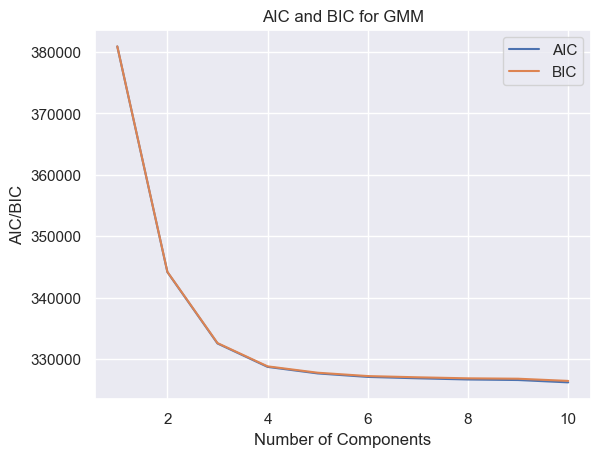

In [89]:
uif.GaussianMixtureBinning(df, features, RANDOM_STATE)

In [90]:
# new features
df['TotalDayWaitList_CAT_CAN'] = pd.qcut(df['TotalDayWaitList_CAN'], q=4, labels=['TotalDayWaitList (Min-18)', 'TotalDayWaitList (19-70)', 'TotalDayWaitList (71-233)', 'TotalDayWaitList (234-Max)'])

# category datatype
df['TotalDayWaitList_CAT_CAN'] = df['TotalDayWaitList_CAT_CAN'].astype('category')

# update DataFrame
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['TotalDayWaitList_CAT_CAN'])
df_can = uf.insertIntoDataFrame(df_can, ['TotalDayWaitList_CAT_CAN'])

# add to list
removeCols.extend(features)

In [91]:
uf.categoryContingencySurvival(df, 'TotalDayWaitList_CAT_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
TotalDayWaitList (Min-18),2920.0,3764.0,6684.0,43.686415,56.313585
TotalDayWaitList (19-70),2105.0,4549.0,6654.0,31.635107,68.364893
TotalDayWaitList (71-233),1643.0,4983.0,6626.0,24.796257,75.203743
TotalDayWaitList (234-Max),1833.0,4803.0,6636.0,27.622061,72.377939
Column Total,8501.0,18099.0,26600.0,31.958647,68.041353


In [92]:
# remove features
df, df_dict, df_label, df_can, df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date = uf.HouseKeeping(df, removeCols, df_dict, df_label, df_can,\
                                                                df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date, txt=REMOVE, display=True)

Data Dictionary Updated.
Remove 0 row(s) from df_label DataFrame.
Remove 20 row(s) from df_can DataFrame.
Remove 13 row(s) from df_don DataFrame.
Remove 0 row(s) from df_both DataFrame.
Remove 0 row(s) from df_ordinal DataFrame.
Remove 0 row(s) from df_nominal DataFrame.
Remove 33 row(s) from df_numeric DataFrame.
Remove 22 row(s) from df_drop DataFrame.
Remove 0 row(s) from df_object DataFrame.
Remove 0 row(s) from df_unknown DataFrame.
Remove 0 row(s) from df_date DataFrame.

Removed Features: ['Age_CAN', 'Age_DON', 'BMI_CAN', 'BMI_DON', 'BloodPH_DON', 'BloodUreaNitrogenLevel_DON', 'CreatinineRegistration_CAN', 'CreatinineTransplant_CAN', 'Creatinine_DON', 'Creatinine_Mean_CAN', 'DistanceFromDonorHospitaltoTXCenter', 'HeightCm_CAN', 'HeightCm_DON', 'Hematocrit_DON', 'HemodynamicsRegistration_CO_CAN', 'HemodynamicsRegistration_PA_DIA_CAN', 'HemodynamicsRegistration_PA_MN_CAN', 'HemodynamicsRegistration_PCW_CAN', 'HemodynamicsRegistration_SYS_CAN', 'HemodynamicsTransplant_CO_CAN', 'Hem

### ENCODE

In [93]:
print(sorted(df_ordinal.column.to_list()))

['Age_CAT_CAN', 'Age_CAT_DON', 'BMI_CAT_CAN', 'BMI_CAT_DON', 'Bilirubin_CAT_CAN', 'Bilirubin_CAT_DON', 'BloodUreaNitrogenLevel_CAT_DON', 'CigaretteAbstinence_CAN', 'Creatinine_CAT_CAN', 'Creatinine_CAT_DON', 'DiabetesHistory_DON', 'DistanceFromDonorHospitaltoTXCenter_CAT', 'EducationLevel_CAN', 'FunctionalStatusRegistration_CAN', 'FunctionalStatusTransplant_CAN', 'HeightCm_CAT_CAN', 'HeightCm_CAT_DON', 'Hematocrit_CAT_DON', 'Hemodynamics_Mean_CO_CAT_CAN', 'Hemodynamics_Mean_PA_MN_CAT_CAN', 'IschemicTimeHour_CAT', 'LV_EjectionFractionPercent_CAT_DON', 'MedicalConditionTransplant_CAN', 'MismatchLevel_AMIS', 'MismatchLevel_BMIS', 'MismatchLevel_DRMIS', 'MismatchLevel_HLMIS', 'OrganRecovery_PCO2_CAT_DON', 'PreviousTransplantNumber_CAN', 'SOGT_ALT_CAT_DON', 'SOGT_AST_CAT_DON', 'TotalDayWaitList_CAT_CAN', 'TransfusionNumber_DON', 'WeightKg_CAT_CAN', 'WeightKg_CAT_DON']


#### Age

In [94]:
features = uf.getFeatureList(df, 'Age_')

             count unique           top  freq
Age_CAT_CAN  26600      4    Age(57-63)  6789
Age_CAT_DON  26600      4  Age (Min-23)  6989

:::: NaN Count:
Age_CAT_CAN    0
Age_CAT_DON    0


In [95]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['Age (Min-46)', 'Age(47-56)', 'Age(57-63)', 'Age(65-Max)'] Age_CAT_CAN
['Age (Min-23)', 'Age(24-31)', 'Age(32-40)', 'Age(41-Max)'] Age_CAT_DON


In [96]:
# order
ordering = sorted(df.Age_CAT_DON.unique())
ordering

['Age (Min-23)', 'Age(24-31)', 'Age(32-40)', 'Age(41-Max)']

In [97]:
# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
df['Age_CAT_DON'] = encoder.fit_transform(df[['Age_CAT_DON']])

In [98]:
# order
ordering = sorted(df.Age_CAT_CAN.unique())
ordering

['Age (Min-46)', 'Age(47-56)', 'Age(57-63)', 'Age(65-Max)']

In [99]:
# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
df['Age_CAT_CAN'] = encoder.fit_transform(df[['Age_CAT_CAN']])

#### BMI

In [100]:
features = uf.getFeatureList(df, 'BMI_')

             count unique      top   freq
BMI_CAT_CAN  26600      3  Obesity  26191
BMI_CAT_DON  26600      3  Obesity  26388

:::: NaN Count:
BMI_CAT_CAN    0
BMI_CAT_DON    0


In [101]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['Normal Weight', 'Obesity', 'Over Weight'] BMI_CAT_CAN
['Normal Weight', 'Obesity', 'Over Weight'] BMI_CAT_DON


In [102]:
# order
ordering = ['Normal Weight', 'Over Weight', 'Obesity']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### Bilirubin

In [103]:
features = uf.getFeatureList(df, 'Bilirubin')

                   count unique     top   freq
Bilirubin_CAT_CAN  26600      3  Normal  21516
Bilirubin_CAT_DON  26600      3  Normal  20897

:::: NaN Count:
Bilirubin_CAT_CAN    0
Bilirubin_CAT_DON    0


In [104]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['High', 'Normal', 'Unknown'] Bilirubin_CAT_CAN
['High', 'Normal', 'Unknown'] Bilirubin_CAT_DON


In [105]:
# order
ordering = ['Unknown', 'Normal', 'High']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### BloodUreaNitrogenLevel

In [106]:
features = uf.getFeatureList(df, 'BloodUreaNitrogenLevel')

                                count unique     top   freq
BloodUreaNitrogenLevel_CAT_DON  26600      4  Normal  17157

:::: NaN Count:
BloodUreaNitrogenLevel_CAT_DON    0


In [107]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['High', 'Low', 'Normal', 'Unknown'] BloodUreaNitrogenLevel_CAT_DON


In [108]:
# order
ordering = ['Unknown', 'Low', 'Normal', 'High']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### Cigarette

In [109]:
features = uf.getFeatureList(df, 'Cigarette')

                         count unique      top   freq
CigaretteAbstinence_CAN  26600      9  Unknown  15355
CigaretteHistory_DON     26600      3       No  23136
CigaretteUse_CAN         26600      3       No  14924

:::: NaN Count:
CigaretteAbstinence_CAN    0
CigaretteHistory_DON       0
CigaretteUse_CAN           0


In [110]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['0-2 months', '13-24 months', '25-36 months', '3-12 months', '37-48 months', '49-60 months', '>60 months', 'Continues to smoke', 'Unknown'] CigaretteAbstinence_CAN
['No', 'Unknown', 'Yes'] CigaretteHistory_DON
['No', 'Unknown', 'Yes'] CigaretteUse_CAN


In [111]:
# testing for independance
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
1,CigaretteAbstinence_CAN,CigaretteUse_CAN,24978.992473,0.00000,0.685223
0,CigaretteAbstinence_CAN,CigaretteHistory_DON,21.914628,0.14597,0.020296
2,CigaretteHistory_DON,CigaretteUse_CAN,3.161082,0.53124,0.007708


In [112]:
df.CigaretteAbstinence_CAN.value_counts()

CigaretteAbstinence_CAN
Unknown               15355
>60 months             6614
3-12 months            1946
13-24 months            927
25-36 months            568
37-48 months            452
49-60 months            384
0-2 months              304
Continues to smoke       50
Name: count, dtype: int64

In [113]:
# add to removeCols list
removeCols = ['CigaretteAbstinence_CAN']

#### Creatinine

In [114]:
features = uf.getFeatureList(df, 'Creatinine')

                    count unique     top   freq
Creatinine_CAT_CAN  26600      4  Normal  14814
Creatinine_CAT_DON  26600      4  Normal  15527

:::: NaN Count:
Creatinine_CAT_CAN    0
Creatinine_CAT_DON    0


In [115]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['Elevated', 'Low', 'Normal', 'Unknown'] Creatinine_CAT_CAN
['Elevated', 'Low', 'Normal', 'Unknown'] Creatinine_CAT_DON


In [116]:
# order
ordering = ['Unknown', 'Low', 'Normal', 'Elevated']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### Diabetes

In [117]:
features = uf.getFeatureList(df, 'Diabetes')

                     count unique top   freq
DiabetesHistory_DON  26600      6  No  25440
DiabetesType_CAN     26600      6  No  18877
Diabetes_DON         26600      3  No  25440

:::: NaN Count:
DiabetesHistory_DON    0
DiabetesType_CAN       0
Diabetes_DON           0


In [118]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['No', 'Unknown', 'Yes, 0-5 Years', 'Yes, 6-10 Years', 'Yes, >10 Years', 'Yes, Duration Unknown'] DiabetesHistory_DON
['No', 'Type I', 'Type II', 'Type Other', 'Type Unknown', 'Unknown'] DiabetesType_CAN
['No', 'Unknown', 'Yes'] Diabetes_DON


In [119]:
# testing for independance
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
1,DiabetesHistory_DON,Diabetes_DON,53200.000000,0.000000,1.000000
2,DiabetesType_CAN,Diabetes_DON,6.992087,0.726192,0.011464
0,DiabetesHistory_DON,DiabetesType_CAN,14.078117,0.960354,0.010288


In [120]:
# add to removeCols list
removeCols.extend(['DiabetesHistory_DON'])

#### DistanceFromDonorHospitaltoTXCenter_CAT

In [121]:
features = uf.getFeatureList(df, 'Distance')

                                         count unique               top  freq
DistanceFromDonorHospitaltoTXCenter_CAT  26600      4  Distance(Min-37)  6663

:::: NaN Count:
DistanceFromDonorHospitaltoTXCenter_CAT    0


In [122]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['Distance(167-354)', 'Distance(354-Max)', 'Distance(38-167)', 'Distance(Min-37)'] DistanceFromDonorHospitaltoTXCenter_CAT


In [123]:
# order
ordering = ['Distance(Min-37)', 'Distance(38-167)', 'Distance(167-354)', 'Distance(354-Max)']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### EducationLevel_CAN

In [124]:
features = uf.getFeatureList(df, 'EducationLevel_CAN')

                    count unique                        top  freq
EducationLevel_CAN  26600      7  HIGH SCHOOL (9-12) or GED  9807

:::: NaN Count:
EducationLevel_CAN    0


In [125]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['ASSOCIATE/BACHELOR DEGREE', 'ATTENDED COLLEGE/TECHNICAL SCHOOL', 'GRADE SCHOOL (0-8)', 'HIGH SCHOOL (9-12) or GED', 'NONE', 'POST-COLLEGE GRADUATE DEGREE', 'Unknown'] EducationLevel_CAN


In [126]:
# order
ordering = ['Unknown', 'NONE', 'GRADE SCHOOL (0-8)', 'HIGH SCHOOL (9-12) or GED', 'ATTENDED COLLEGE/TECHNICAL SCHOOL', 'ASSOCIATE/BACHELOR DEGREE', 'POST-COLLEGE GRADUATE DEGREE']
# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### FunctionalStatus

In [127]:
features = uf.getFeatureList(df, 'FunctionalStatus')

                                  count unique                                                                     top  freq
FunctionalStatusRegistration_CAN  26600     11  20% - Very sick, hospitalization necessary: active treatment necessary  6150
FunctionalStatusTransplant_CAN    26600     11  20% - Very sick, hospitalization necessary: active treatment necessary  7833

:::: NaN Count:
FunctionalStatusRegistration_CAN    0
FunctionalStatusTransplant_CAN      0


In [128]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['10% - Moribund, fatal processes progressing rapidly', '100% - Normal, no complaints, no evidence of disease', '20% - Very sick, hospitalization necessary: active treatment necessary', '30% - Severely disabled: hospitalization is indicated, death not imminent', '40% - Disabled: requires special care and assistance', '50% - Requires considerable assistance and frequent medical care', '60% - Requires occasional assistance but is able to care for needs', '70% - Cares for self: unable to carry on normal activity or active work', '80% - Normal activity with effort: some symptoms of disease', '90% - Able to carry on normal activity: minor symptoms of disease', 'Unknown'] FunctionalStatusRegistration_CAN
['10% - Moribund, fatal processes progressing rapidly', '100% - Normal, no complaints, no evidence of disease', '20% - Very sick, hospitalization necessary: active treatment necessary', '30% - Severely disabled: hospitalization is indicated, death not imminent', '40% - Disabled: requires spe

In [129]:
# testing for independance
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,FunctionalStatusRegistration_CAN,FunctionalStatusTransplant_CAN,26988.585869,0.0,0.318529


In [130]:
# sort the list, placing "Unknown" first
ordering = ['Unknown'] + sorted(
    [status for status in df.FunctionalStatusTransplant_CAN.unique().tolist() if status != 'Unknown'],
    key=lambda x: int(x.split('%')[0])
)
print(ordering)

['Unknown', '10% - Moribund, fatal processes progressing rapidly', '20% - Very sick, hospitalization necessary: active treatment necessary', '30% - Severely disabled: hospitalization is indicated, death not imminent', '40% - Disabled: requires special care and assistance', '50% - Requires considerable assistance and frequent medical care', '60% - Requires occasional assistance but is able to care for needs', '70% - Cares for self: unable to carry on normal activity or active work', '80% - Normal activity with effort: some symptoms of disease', '90% - Able to carry on normal activity: minor symptoms of disease', '100% - Normal, no complaints, no evidence of disease']


In [131]:
# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### HeightCm

In [132]:
features = uf.getFeatureList(df, 'HeightCm')

                  count unique                 top  freq
HeightCm_CAT_CAN  26600      4  HeightCm (Min-168)  8158
HeightCm_CAT_DON  26600      4   HeightCm(169-175)  7332

:::: NaN Count:
HeightCm_CAT_CAN    0
HeightCm_CAT_DON    0


In [133]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['HeightCm (Min-168)', 'HeightCm(169-175)', 'HeightCm(176-181)', 'HeightCm(182-Max)'] HeightCm_CAT_CAN
['HeightCm (Min-168)', 'HeightCm(169-175)', 'HeightCm(176-181)', 'HeightCm(182-Max)'] HeightCm_CAT_DON


In [134]:
ordering = sorted(df.HeightCm_CAT_CAN.unique())
ordering

['HeightCm (Min-168)',
 'HeightCm(169-175)',
 'HeightCm(176-181)',
 'HeightCm(182-Max)']

In [135]:
# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### Hematocrit_CAT_DON

In [136]:
features = uf.getFeatureList(df, 'Hematocrit')

                    count unique  top   freq
Hematocrit_CAT_DON  26600      4  Low  25848

:::: NaN Count:
Hematocrit_CAT_DON    0


In [137]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['Elevated', 'Low', 'Normal', 'Unknown'] Hematocrit_CAT_DON


In [138]:
# order
ordering = ['Unknown', 'Low', 'Normal', 'Elevated']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### Hemodynamics_Mean

In [139]:
features = uf.getFeatureList(df, 'Hemodynamics_Mean')

                                 count unique   top   freq
Hemodynamics_Mean_CO_CAT_CAN     26600      4   Low  18749
Hemodynamics_Mean_PA_MN_CAT_CAN  26600      5  High  13276

:::: NaN Count:
Hemodynamics_Mean_CO_CAT_CAN       0
Hemodynamics_Mean_PA_MN_CAT_CAN    0


In [140]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['High', 'Low', 'Normal', 'Unknown'] Hemodynamics_Mean_CO_CAT_CAN
['Extreme', 'High', 'Low', 'Normal', 'Unknown'] Hemodynamics_Mean_PA_MN_CAT_CAN


In [141]:
# order
ordering = ['Unknown', 'Low', 'Normal', 'High']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
df['Hemodynamics_Mean_CO_CAT_CAN'] = encoder.fit_transform(df[['Hemodynamics_Mean_CO_CAT_CAN']])

In [142]:
# order
ordering = ['Unknown', 'Low', 'Normal', 'High', 'Extreme']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
df['Hemodynamics_Mean_PA_MN_CAT_CAN'] = encoder.fit_transform(df[['Hemodynamics_Mean_PA_MN_CAT_CAN']])

#### IschemicTimeHour

In [143]:
features = uf.getFeatureList(df, 'IschemicTimeHour')

                      count unique     top   freq
IschemicTimeHour_CAT  26600      4  Normal  13804

:::: NaN Count:
IschemicTimeHour_CAT    0


In [144]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['High', 'Low', 'Normal', 'Unknown'] IschemicTimeHour_CAT


In [145]:
# order
ordering = ['Unknown', 'Low', 'Normal', 'High']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### LV_EjectionFractionPercent

In [146]:
features = uf.getFeatureList(df, 'LV_EjectionFractionPercent')

                                    count unique     top   freq
LV_EjectionFractionPercent_CAT_DON  26600      6  Normal  23741

:::: NaN Count:
LV_EjectionFractionPercent_CAT_DON    0


In [147]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['Below Normal', 'Mildly Abnormal', 'Moderately Abnormal', 'Normal', 'Severely Abnormal', 'Unknown'] LV_EjectionFractionPercent_CAT_DON


In [148]:
# order
ordering = ['Unknown','Below Normal', 'Normal', 'Mildly Abnormal', 'Moderately Abnormal', 'Severely Abnormal']
ordering                 

['Unknown',
 'Below Normal',
 'Normal',
 'Mildly Abnormal',
 'Moderately Abnormal',
 'Severely Abnormal']

In [149]:
# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### MedicalConditionTransplant_CAN

In [150]:
features = uf.getFeatureList(df, 'MedicalConditionTransplan')

                                count unique               top   freq
MedicalConditionTransplant_CAN  26600      4  Not Hospitalized  12279

:::: NaN Count:
MedicalConditionTransplant_CAN    0


In [151]:
for feature in features:
    print((df[feature].unique()), feature)

['In Intensive Care Unit', 'Not Hospitalized', 'Hospitalized Not in ICU', 'Unknown']
Categories (4, object): ['Hospitalized Not in ICU', 'In Intensive Care Unit', 'Unknown', 'Not Hospitalized'] MedicalConditionTransplant_CAN


In [152]:
# order
ordering = ['Unknown', 'Not Hospitalized', 'Hospitalized Not in ICU', 'In Intensive Care Unit']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### MismatchLevel

In [153]:
features = uf.getFeatureList(df, 'MismatchLevel')

                     count  unique  top   freq
MismatchLevel_AMIS   26600       4    2  12638
MismatchLevel_BMIS   26600       4    2  17616
MismatchLevel_DRMIS  26600       4    2  13426
MismatchLevel_HLMIS  26600       8    5   9113

:::: NaN Count:
MismatchLevel_AMIS     0
MismatchLevel_BMIS     0
MismatchLevel_DRMIS    0
MismatchLevel_HLMIS    0


In [154]:
for feature in features:
    print((df[feature].unique()), feature)

[2, 1, 0, 999]
Categories (4, int64): [0, 1, 2, 999] MismatchLevel_AMIS
[2, 1, 999, 0]
Categories (4, int64): [0, 1, 2, 999] MismatchLevel_BMIS
[1, 2, 999, 0]
Categories (4, int64): [0, 1, 2, 999] MismatchLevel_DRMIS
[5, 3, 6, 4, 999, 2, 1, 0]
Categories (8, int64): [0, 1, 2, 3, 4, 5, 6, 999] MismatchLevel_HLMIS


In [155]:
# convert to string
df[features] = df[features].astype(str)

# iterate features to encode
for feature in features:
    # sorting
    ordering = ['999'] + sorted([x for x in df[feature].unique() if x != '999'])
    # initialize encoder
    encoder = OrdinalEncoder(categories=[ordering])
    df[feature] = encoder.fit_transform(df[[feature]])

#### OrganRecovery_PCO2_CAT_DON

In [156]:
features = uf.getFeatureList(df, 'OrganRecovery_PCO2')

                            count unique     top   freq
OrganRecovery_PCO2_CAT_DON  26600      4  Normal  15271

:::: NaN Count:
OrganRecovery_PCO2_CAT_DON    0


In [157]:
for feature in features:
    print((df[feature].unique()), feature)

['Normal', 'Low', 'High', 'Unknown']
Categories (4, object): ['High', 'Low', 'Normal', 'Unknown'] OrganRecovery_PCO2_CAT_DON


In [158]:
# order
ordering = ['Unknown', 'Low', 'Normal', 'High']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### PreviousTransplantNumber_CAN

In [159]:
features = uf.getFeatureList(df, 'PreviousTransplantNumber')

                              count  unique  top   freq
PreviousTransplantNumber_CAN  26600       4    0  25759

:::: NaN Count:
PreviousTransplantNumber_CAN    0


In [160]:
for feature in features:
    print((df[feature].unique()), feature)

[0, 1, 2, 3]
Categories (4, int64): [0, 1, 2, 3] PreviousTransplantNumber_CAN


In [161]:
# convert to float
df[features] = df[features].astype('float')

#### SOGT

In [162]:
features = uf.getFeatureList(df, 'SOGT')

                  count unique     top   freq
SOGT_ALT_CAT_DON  26600      4  Normal  16580
SOGT_AST_CAT_DON  26600      4  Normal  13344

:::: NaN Count:
SOGT_ALT_CAT_DON    0
SOGT_AST_CAT_DON    0


In [163]:
for feature in features:
    print((df[feature].unique()), feature)

['Normal', 'High', 'Low', 'Unknown']
Categories (4, object): ['High', 'Low', 'Normal', 'Unknown'] SOGT_ALT_CAT_DON
['High', 'Normal', 'Low', 'Unknown']
Categories (4, object): ['High', 'Low', 'Normal', 'Unknown'] SOGT_AST_CAT_DON


In [164]:
# order
ordering = ['Unknown', 'Low', 'Normal', 'High']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### TotalDayWaitList_CAT_CAN

In [165]:
features = uf.getFeatureList(df, 'TotalDayWaitList')

                          count unique                        top  freq
TotalDayWaitList_CAT_CAN  26600      4  TotalDayWaitList (Min-18)  6684

:::: NaN Count:
TotalDayWaitList_CAT_CAN    0


In [166]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['TotalDayWaitList (19-70)', 'TotalDayWaitList (234-Max)', 'TotalDayWaitList (71-233)', 'TotalDayWaitList (Min-18)'] TotalDayWaitList_CAT_CAN


In [167]:
# order
ordering = ['TotalDayWaitList (Min-18)', 'TotalDayWaitList (19-70)', 'TotalDayWaitList (71-233)', 'TotalDayWaitList (234-Max)']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### TransfusionNumber

In [168]:
features = uf.getFeatureList(df, 'TransfusionNumber')

                       count unique   top   freq
TransfusionNumber_DON  26600      5  NONE  12812

:::: NaN Count:
TransfusionNumber_DON    0


In [169]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['1 - 5', '6 - 10', 'GREATER THAN 10', 'NONE', 'Unknown'] TransfusionNumber_DON


In [170]:
# order
ordering = ['Unknown', 'NONE', '1 - 5', '6 - 10', 'GREATER THAN 10']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### WeightKg

In [171]:
features = uf.getFeatureList(df, 'WeightKg')

                  count unique                top  freq
WeightKg_CAT_CAN  26600      4  WeightKg (Min-70)  6730
WeightKg_CAT_DON  26600      4  WeightKg (Min-70)  7003

:::: NaN Count:
WeightKg_CAT_CAN    0
WeightKg_CAT_DON    0


In [172]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['WeightKg (Min-70)', 'WeightKg(71-83)', 'WeightKg(84-96)', 'WeightKg(97-Max)'] WeightKg_CAT_CAN
['WeightKg (Min-70)', 'WeightKg(70-81)', 'WeightKg(82-94)', 'WeightKg(95-Max)'] WeightKg_CAT_DON


In [173]:
# iterate features and encode
for feature in features:
    # order
    ordering = sorted(df[feature].unique())
    # initialize encoder
    encoder = OrdinalEncoder(categories=[ordering])
    # encode
    df[feature] = encoder.fit_transform(df[[feature]])

In [174]:
# remove features
df, df_dict, df_label, df_can, df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date = uf.HouseKeeping(df, removeCols, df_dict, df_label, df_can,\
                                                                df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date, txt=REMOVE, display=True)

Data Dictionary Updated.
Remove 0 row(s) from df_label DataFrame.
Remove 1 row(s) from df_can DataFrame.
Remove 1 row(s) from df_don DataFrame.
Remove 0 row(s) from df_both DataFrame.
Remove 2 row(s) from df_ordinal DataFrame.
Remove 1 row(s) from df_nominal DataFrame.
Remove 0 row(s) from df_numeric DataFrame.
Remove 0 row(s) from df_drop DataFrame.
Remove 0 row(s) from df_object DataFrame.
Remove 0 row(s) from df_unknown DataFrame.
Remove 0 row(s) from df_date DataFrame.

Removed Features: ['CigaretteAbstinence_CAN', 'DiabetesHistory_DON']

Total Row(s) & Column(s) Before Removing Column(s): 26,600 & columns: 202
Total Row(s) & Column(s) After Removing Column(s): 26,600 & columns: 200


In [175]:
df[df_ordinal.column.to_list()].head()

,MismatchLevel_AMIS,MismatchLevel_HLMIS,MismatchLevel_BMIS,MismatchLevel_DRMIS,PreviousTransplantNumber_CAN,EducationLevel_CAN,FunctionalStatusRegistration_CAN,FunctionalStatusTransplant_CAN,MedicalConditionTransplant_CAN,TransfusionNumber_DON,Age_CAT_CAN,Age_CAT_DON,HeightCm_CAT_CAN,HeightCm_CAT_DON,WeightKg_CAT_CAN,WeightKg_CAT_DON,BMI_CAT_CAN,BMI_CAT_DON,BloodUreaNitrogenLevel_CAT_DON,Creatinine_CAT_CAN,Creatinine_CAT_DON,DistanceFromDonorHospitaltoTXCenter_CAT,Hematocrit_CAT_DON,Hemodynamics_Mean_PA_MN_CAT_CAN,Hemodynamics_Mean_CO_CAT_CAN,IschemicTimeHour_CAT,LV_EjectionFractionPercent_CAT_DON,SOGT_AST_CAT_DON,SOGT_ALT_CAT_DON,OrganRecovery_PCO2_CAT_DON,Bilirubin_CAT_CAN,Bilirubin_CAT_DON,TotalDayWaitList_CAT_CAN
0,3.0,6.0,3.0,2.0,0.0,4.0,1.0,1.0,3.0,2.0,0.0,1.0,1.0,1.0,0.0,3.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,3.0,1.0,3.0,2.0,3.0,2.0,2.0,2.0,1.0,0.0
1,2.0,6.0,3.0,3.0,0.0,3.0,1.0,9.0,1.0,3.0,0.0,1.0,3.0,1.0,1.0,0.0,2.0,2.0,3.0,3.0,2.0,0.0,1.0,3.0,1.0,2.0,2.0,2.0,3.0,1.0,1.0,1.0,3.0
2,1.0,4.0,2.0,3.0,0.0,4.0,1.0,2.0,2.0,1.0,2.0,0.0,2.0,1.0,3.0,0.0,2.0,2.0,2.0,3.0,2.0,0.0,1.0,3.0,1.0,1.0,2.0,3.0,3.0,2.0,1.0,1.0,1.0
3,3.0,7.0,3.0,3.0,0.0,3.0,2.0,8.0,1.0,1.0,3.0,3.0,2.0,0.0,3.0,3.0,2.0,2.0,3.0,2.0,3.0,2.0,2.0,2.0,1.0,2.0,2.0,3.0,3.0,2.0,1.0,1.0,3.0
4,1.0,5.0,3.0,3.0,0.0,5.0,9.0,9.0,1.0,1.0,3.0,0.0,1.0,3.0,1.0,3.0,2.0,2.0,3.0,2.0,3.0,1.0,1.0,2.0,1.0,2.0,2.0,3.0,3.0,1.0,1.0,1.0,1.0


In [176]:
df[df_ordinal.column.to_list()].dtypes

MismatchLevel_AMIS                         float64
MismatchLevel_HLMIS                        float64
MismatchLevel_BMIS                         float64
MismatchLevel_DRMIS                        float64
PreviousTransplantNumber_CAN               float64
EducationLevel_CAN                         float64
FunctionalStatusRegistration_CAN           float64
FunctionalStatusTransplant_CAN             float64
MedicalConditionTransplant_CAN             float64
TransfusionNumber_DON                      float64
Age_CAT_CAN                                float64
Age_CAT_DON                                float64
HeightCm_CAT_CAN                           float64
HeightCm_CAT_DON                           float64
WeightKg_CAT_CAN                           float64
WeightKg_CAT_DON                           float64
BMI_CAT_CAN                                float64
BMI_CAT_DON                                float64
BloodUreaNitrogenLevel_CAT_DON             float64
Creatinine_CAT_CAN             

### Nominal

In [177]:
print(sorted(df_nominal.column.to_list()))

['AllocationType_DON', 'AntiHypertensive_DON', 'AntibodyResultHBSAB_DON', 'AntibodyResultRPR_VDRL_DON', 'Antibody_HEP_C_DON', 'AntigenBW4_CAN', 'AntigenBW6_CAN', 'AntigenC1_CAN', 'AntigenC2_CAN', 'AntigenDA1_DON', 'AntigenDA2_DON', 'AntigenDB1_DON', 'AntigenDB2_DON', 'AntigenDQ1_CAN', 'AntigenDQ2_CAN', 'AntigenDR1_DON', 'AntigenDR2_DON', 'AntigenDR51_2_CAN', 'AntigenDR51_CAN', 'AntigenDR52_2_CAN', 'AntigenDR52_CAN', 'AntigenDR53_2_CAN', 'AntigenDR53_CAN', 'AntigenRA1_CAN', 'AntigenRA2_CAN', 'AntigenRB1_CAN', 'AntigenRB2_CAN', 'AntigenRDR1_CAN', 'AntigenRDR2_CAN', 'ArginnieManagement_DON', 'Biopsy_DON', 'BloodGroupMatchLevel', 'BloodGroup_CAN', 'BloodGroup_DON', 'BloodInfectionSource_DON', 'BloodPH_CAT_DON', 'BronchoscopyLeft_DON', 'BronchoscopyRight_DON', 'CMVStatus_Transplant_CAN', 'CMV_IGG_Transplant_CAN', 'CMV_IGM_Transplant_CAN', 'CancerExtraCranial_DON', 'CancerHistory_DON', 'CancerIntraCranial_DON', 'CancerSkin_DON', 'CardiacArrest_DON', 'CauseOfDeath_DON', 'CerebroVascularDiseas

#### AllocationType_DON

In [178]:
features = uf.getFeatureList(df, 'AllocationType_DON')

                    count unique    top   freq
AllocationType_DON  26600      4  Local  13598

:::: NaN Count:
AllocationType_DON    0


In [179]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
Foreign Donor     5.0     19.0       24.0  20.833333  79.166667
Local          2756.0  10842.0    13598.0  20.267686  79.732314
National       3509.0   4422.0     7931.0  44.244105  55.755895
Regional       2231.0   2816.0     5047.0  44.204478  55.795522
Column Total   8501.0  18099.0    26600.0  31.958647  68.041353




#### AntiHypertensive_DON

In [180]:
features = uf.getFeatureList(df, 'AntiHypertensive_DON')

                      count unique top   freq
AntiHypertensive_DON  26600      3  No  17756

:::: NaN Count:
AntiHypertensive_DON    0


In [181]:
for feature in features:
    print(uf.categoryContingencySurvival(df, feature, 'Survival'))
    print('\n')

Survival        Dead   Living  Row Total     Dead %   Living %
No            5585.0  12171.0    17756.0  31.454156  68.545844
Unknown         21.0     28.0       49.0  42.857143  57.142857
Yes           2895.0   5900.0     8795.0  32.916430  67.083570
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353




#### Antibody
- Hepatitis_B_CoreAntibody_CAN & SurfaceHBVAntibodyTotalTransplant_CAN & Hepatitis_B_CoreAntibody_DON & Antibody_HEP_C_DON & AntibodyResultRPR_VDRL_DON & AntibodyResultHBSAB_DON & PanelReactiveAntibody_CPRA_CAT_CAN

In [182]:
features = uf.getFeatureList(df, 'Antibody')

                                       count unique       top   freq
AntibodyResultHBSAB_DON                26600      4   Unknown  22730
AntibodyResultRPR_VDRL_DON             26600      3  Negative  25876
Antibody_HEP_C_DON                     26600      3  Negative  25230
Hepatitis_B_CoreAntibody_CAN           26600      3  Negative  24109
Hepatitis_B_CoreAntibody_DON           26600      3  Negative  26049
SurfaceHBVAntibodyTotalTransplant_CAN  26600      5  Negative  13107

:::: NaN Count:
AntibodyResultHBSAB_DON                  0
AntibodyResultRPR_VDRL_DON               0
Antibody_HEP_C_DON                       0
Hepatitis_B_CoreAntibody_CAN             0
Hepatitis_B_CoreAntibody_DON             0
SurfaceHBVAntibodyTotalTransplant_CAN    0


In [183]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features).head()

,column1,column2,chi2,p_value,cramer_v
10,Antibody_HEP_C_DON,Hepatitis_B_CoreAntibody_DON,2312.644666,0.000000e+00,0.208496
13,Hepatitis_B_CoreAntibody_CAN,SurfaceHBVAntibodyTotalTransplant_CAN,1553.346427,0.000000e+00,0.170875
11,Antibody_HEP_C_DON,SurfaceHBVAntibodyTotalTransplant_CAN,500.899614,4.510806e-103,0.097033
8,AntibodyResultRPR_VDRL_DON,SurfaceHBVAntibodyTotalTransplant_CAN,486.533292,5.446294e-100,0.095631
3,AntibodyResultHBSAB_DON,Hepatitis_B_CoreAntibody_DON,461.825899,1.397682e-96,0.093172


#### Antigen

##### Antigen

In [184]:
features = uf.getFeatureList(df, '^Antigen.*_CAN')

                   count unique       top   freq
AntigenBW4_CAN     26600      3  Negative  20837
AntigenBW6_CAN     26600      3  Negative  18902
AntigenC1_CAN      26600      2  Negative  17944
AntigenC2_CAN      26600      2  Negative  18731
AntigenDQ1_CAN     26600      2  Negative  17687
AntigenDQ2_CAN     26600      2  Negative  18755
AntigenDR51_2_CAN  26600      3  Negative  25176
AntigenDR51_CAN    26600      3  Negative  19077
AntigenDR52_2_CAN  26600      3  Negative  25100
AntigenDR52_CAN    26600      3  Negative  18556
AntigenDR53_2_CAN  26600      3  Negative  25171
AntigenDR53_CAN    26600      3  Negative  18838
AntigenRA1_CAN     26600      3  Positive  24436
AntigenRA2_CAN     26600      3  Positive  22200
AntigenRB1_CAN     26600      3  Positive  24437
AntigenRB2_CAN     26600      3  Positive  23290
AntigenRDR1_CAN    26600      3  Positive  24437
AntigenRDR2_CAN    26600      3  Positive  22785

:::: NaN Count:
AntigenBW4_CAN       0
AntigenBW6_CAN       0
Antige

In [185]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features).head(20)

,column1,column2,chi2,p_value,cramer_v
148,AntigenRB1_CAN,AntigenRDR1_CAN,52111.642657,0.0,0.989718
141,AntigenRA1_CAN,AntigenRDR1_CAN,51941.421128,0.0,0.988100
139,AntigenRA1_CAN,AntigenRB1_CAN,51623.860247,0.0,0.985075
90,AntigenDR51_2_CAN,AntigenDR53_2_CAN,49598.313659,0.0,0.965556
34,AntigenC1_CAN,AntigenDQ1_CAN,24529.414374,0.0,0.960291
101,AntigenDR51_CAN,AntigenDR53_CAN,47135.763410,0.0,0.941281
109,AntigenDR52_2_CAN,AntigenDR53_2_CAN,47002.526965,0.0,0.939950
88,AntigenDR51_2_CAN,AntigenDR52_2_CAN,46962.123839,0.0,0.939546
99,AntigenDR51_CAN,AntigenDR52_CAN,46844.499251,0.0,0.938369
33,AntigenC1_CAN,AntigenC2_CAN,23065.266121,0.0,0.931190


In [186]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features).tail(20)

,column1,column2,chi2,p_value,cramer_v
16,AntigenBW4_CAN,AntigenRDR2_CAN,631.493984,2.363394e-135,0.108950
12,AntigenBW4_CAN,AntigenRA2_CAN,619.602910,8.859733e-133,0.107920
112,AntigenDR52_2_CAN,AntigenRA2_CAN,183.232383,1.507580e-38,0.058687
127,AntigenDR53_2_CAN,AntigenRA2_CAN,176.501938,4.204402e-37,0.057600
93,AntigenDR51_2_CAN,AntigenRA2_CAN,172.866848,2.535820e-36,0.057003
116,AntigenDR52_2_CAN,AntigenRDR2_CAN,163.021850,3.286749e-34,0.055356
97,AntigenDR51_2_CAN,AntigenRDR2_CAN,154.496936,2.212546e-32,0.053889
114,AntigenDR52_2_CAN,AntigenRB2_CAN,153.663809,3.337994e-32,0.053744
131,AntigenDR53_2_CAN,AntigenRDR2_CAN,153.065149,4.485485e-32,0.053639
129,AntigenDR53_2_CAN,AntigenRB2_CAN,147.314773,7.657312e-31,0.052622


In [187]:
features = uf.getFeatureList(df, '^Antigen.*_DON')

                count unique       top   freq
AntigenDA1_DON  26600      2  Positive  26597
AntigenDA2_DON  26600      3  Positive  24374
AntigenDB1_DON  26600      2  Positive  26597
AntigenDB2_DON  26600      3  Positive  25419
AntigenDR1_DON  26600      2  Positive  26595
AntigenDR2_DON  26600      3  Positive  24799

:::: NaN Count:
AntigenDA1_DON    0
AntigenDA2_DON    0
AntigenDB1_DON    0
AntigenDB2_DON    0
AntigenDR1_DON    0
AntigenDR2_DON    0


In [188]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features).head(20)

,column1,column2,chi2,p_value,cramer_v
1,AntigenDA1_DON,AntigenDB1_DON,18471.388804,0.0,0.833315
3,AntigenDA1_DON,AntigenDR1_DON,11081.666494,0.0,0.645449
10,AntigenDB1_DON,AntigenDR1_DON,11081.666494,0.0,0.645449
14,AntigenDR1_DON,AntigenDR2_DON,8309.061854,0.0,0.558901
0,AntigenDA1_DON,AntigenDA2_DON,7252.363390,0.0,0.522154
5,AntigenDA2_DON,AntigenDB1_DON,7252.363390,0.0,0.522154
2,AntigenDA1_DON,AntigenDB2_DON,6136.153586,0.0,0.480294
9,AntigenDB1_DON,AntigenDB2_DON,6136.153586,0.0,0.480294
4,AntigenDA1_DON,AntigenDR2_DON,4985.062225,0.0,0.432907
11,AntigenDB1_DON,AntigenDR2_DON,4985.062225,0.0,0.432907


#### ArginnieManagement_DON

In [189]:
features = uf.getFeatureList(df, 'Arginnie')

                        count unique  top   freq
ArginnieManagement_DON  26600      3  Yes  18424

:::: NaN Count:
ArginnieManagement_DON    0


In [190]:
uf.categoryContingencySurvival(df, 'ArginnieManagement_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
No,2546.0,5583.0,8129.0,31.319966,68.680034
Unknown,22.0,25.0,47.0,46.808511,53.191489
Yes,5933.0,12491.0,18424.0,32.202562,67.797438
Column Total,8501.0,18099.0,26600.0,31.958647,68.041353


#### Biopsy_DON (REMOVE)

In [191]:
features = uf.getFeatureList(df, 'Biopsy')

            count unique              top   freq
Biopsy_DON  26600      4  Biopsy not done  26531

:::: NaN Count:
Biopsy_DON    0


In [192]:
uf.categoryContingencySurvival(df, features)

Survival,Dead,Living,Row Total,Dead %,Living %
Biopsy not done,8475.0,18056.0,26531.0,31.943764,68.056236
Unknown,23.0,26.0,49.0,46.938776,53.061224
"Yes, rejection confirmed",2.0,7.0,9.0,22.222222,77.777778
"Yes, rejection not confirmed",1.0,10.0,11.0,9.090909,90.909091
Column Total,8501.0,18099.0,26600.0,31.958647,68.041353


In [193]:
# add to lis: No Value added
removeCols = features

#### BloodGroup
- BloodGroup_CAN & BloodGroup_DON & BloodGroupMatchLevel

In [194]:
features = uf.getFeatureList(df, 'BloodGroup')

                      count unique        top   freq
BloodGroupMatchLevel  26600      3  Identical  22701
BloodGroup_CAN        26600      8          A  10581
BloodGroup_DON        26600      8          O  13405

:::: NaN Count:
BloodGroupMatchLevel    0
BloodGroup_CAN          0
BloodGroup_DON          0


In [195]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
2,BloodGroup_CAN,BloodGroup_DON,44202.890193,0.0,0.487232
0,BloodGroupMatchLevel,BloodGroup_CAN,5707.441733,0.0,0.327540
1,BloodGroupMatchLevel,BloodGroup_DON,1599.685182,0.0,0.173405


In [196]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead   Living  Row Total      Dead %   Living %
Compatible    1277.0   2621.0     3898.0   32.760390  67.239610
Identical     7223.0  15478.0    22701.0   31.817982  68.182018
Incompatible     1.0      0.0        1.0  100.000000   0.000000
Column Total  8501.0  18099.0    26600.0   31.958647  68.041353


Survival        Dead   Living  Row Total     Dead %   Living %
A             3255.0   7326.0    10581.0  30.762688  69.237312
A1              29.0     35.0       64.0  45.312500  54.687500
A1B              2.0      3.0        5.0  40.000000  60.000000
A2               5.0      2.0        7.0  71.428571  28.571429
A2B              1.0      3.0        4.0  25.000000  75.000000
AB             444.0   1069.0     1513.0  29.345671  70.654329
B             1345.0   2762.0     4107.0  32.748965  67.251035
O             3420.0   6899.0    10319.0  33.142746  66.857254
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     D

#### BloodPH_CAT_DON

In [197]:
features = uf.getFeatureList(df, 'BloodPH')

                 count unique     top   freq
BloodPH_CAT_DON  26600      4  Normal  15947

:::: NaN Count:
BloodPH_CAT_DON    0


In [198]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
Acidic         977.0   2337.0     3314.0  29.480990  70.519010
Alkaline      2375.0   4901.0     7276.0  32.641561  67.358439
Normal        5122.0  10825.0    15947.0  32.118894  67.881106
Unknown         27.0     36.0       63.0  42.857143  57.142857
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353




#### Bronchoscopy
- BronchoscopyLeft_DON & BronchoscopyRight_DON
- New Feature Bronchoscopy_Combined

In [199]:
features = uf.getFeatureList(df, 'Bronchoscopy')

                       count unique      top   freq
BronchoscopyLeft_DON   26600      3  Unknown  13780
BronchoscopyRight_DON  26600      3  Unknown  13988

:::: NaN Count:
BronchoscopyLeft_DON     0
BronchoscopyRight_DON    0


In [200]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,BronchoscopyLeft_DON,BronchoscopyRight_DON,35170.839612,0.0,0.813084


In [201]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
Abnormal       886.0   2328.0     3214.0  27.566895  72.433105
Normal        2897.0   6709.0     9606.0  30.158234  69.841766
Unknown       4718.0   9062.0    13780.0  34.238026  65.761974
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead %   Living %
Abnormal      1050.0   2560.0     3610.0  29.085873  70.914127
Normal        2713.0   6289.0     9002.0  30.137747  69.862253
Unknown       4738.0   9250.0    13988.0  33.871890  66.128110
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353




In [202]:
# define a function to categorize the results
def categorizeNumericResult(value):
    if value in ['Unknown']:
        return 1
    elif value in ['Normal']:
        return 2
    else:
        return 3

In [203]:
# apply the function
df['BronchoscopyLeft_DON'] = df['BronchoscopyLeft_DON'].apply(categorizeNumericResult).fillna(df.BronchoscopyLeft_DON)
df['BronchoscopyRight_DON'] = df['BronchoscopyRight_DON'].apply(categorizeNumericResult).fillna(df.BronchoscopyRight_DON)

# new feature
df['Bronchoscopy_Combine_Count_DON'] = df[features].sum(axis=1)

# update DataFrame
df_don  = uf.insertIntoDataFrame(df_don, ['Bronchoscopy_Combine_Count_DON'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['Bronchoscopy_Combine_Count_DON'])

# convert to category
df['Bronchoscopy_Combine_Count_DON'] = df['Bronchoscopy_Combine_Count_DON'].astype(float)

# add to list
removeCols.extend(features)

In [204]:
uf.categoryContingencySurvival(df, 'Bronchoscopy_Combine_Count_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
2.0,4616.0,8758.0,13374.0,34.514730,65.485270
3.0,158.0,562.0,720.0,21.944444,78.055556
4.0,2589.0,5968.0,8557.0,30.255931,69.744069
5.0,406.0,968.0,1374.0,29.548763,70.451237
6.0,732.0,1843.0,2575.0,28.427184,71.572816
Column Total,8501.0,18099.0,26600.0,31.958647,68.041353


#### CMV

In [205]:
features = uf.getFeatureList(df, 'CMV')

                          count unique       top   freq
CMVStatus_Transplant_CAN  26600      3  Positive  15005
CMV_IGG_Transplant_CAN    26600      3   Unknown  19458
CMV_IGM_Transplant_CAN    26600      3   Unknown  21290
SerologyAntiCMV_DON       26600      3  Positive  16272

:::: NaN Count:
CMVStatus_Transplant_CAN    0
CMV_IGG_Transplant_CAN      0
CMV_IGM_Transplant_CAN      0
SerologyAntiCMV_DON         0


In [206]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
3,CMV_IGG_Transplant_CAN,CMV_IGM_Transplant_CAN,18148.158956,0.000000e+00,0.584064
0,CMVStatus_Transplant_CAN,CMV_IGG_Transplant_CAN,7158.251297,0.000000e+00,0.366815
1,CMVStatus_Transplant_CAN,CMV_IGM_Transplant_CAN,450.209950,3.912566e-96,0.091992
2,CMVStatus_Transplant_CAN,SerologyAntiCMV_DON,32.420607,1.569434e-06,0.024686
4,CMV_IGG_Transplant_CAN,SerologyAntiCMV_DON,10.408255,3.408449e-02,0.013987
5,CMV_IGM_Transplant_CAN,SerologyAntiCMV_DON,6.146905,1.884426e-01,0.010749


In [207]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
Negative      3594.0   7499.0    11093.0  32.398810  67.601190
Positive      4741.0  10264.0    15005.0  31.596135  68.403865
Unknown        166.0    336.0      502.0  33.067729  66.932271
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead %   Living %
Negative       328.0   2538.0     2866.0  11.444522  88.555478
Positive       513.0   3763.0     4276.0  11.997194  88.002806
Unknown       7660.0  11798.0    19458.0  39.366841  60.633159
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead %   Living %
Negative       598.0   4463.0     5061.0  11.815847  88.184153
Positive        36.0    213.0      249.0  14.457831  85.542169
Unknown       7867.0  13423.0    21290.0  36.951620  63.048380
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead

#### Cancer
- CancerExtraCranial_DON & CancerIntraCranial_DON & CancerHistory_DON & CancerSkin_DON
- Consolidated Cancer_CountTotal_DON

In [208]:
features = uf.getFeatureList(df, 'Cancer')

                        count unique top   freq
CancerExtraCranial_DON  26600      3  No  26367
CancerHistory_DON       26600      3  No  26090
CancerIntraCranial_DON  26600      3  No  26351
CancerSkin_DON          26600      3  No  26392

:::: NaN Count:
CancerExtraCranial_DON    0
CancerHistory_DON         0
CancerIntraCranial_DON    0
CancerSkin_DON            0


In [209]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
2,CancerExtraCranial_DON,CancerSkin_DON,24721.129386,0.0,0.681677
5,CancerIntraCranial_DON,CancerSkin_DON,23449.932450,0.0,0.663919
1,CancerExtraCranial_DON,CancerIntraCranial_DON,23367.764456,0.0,0.662755
3,CancerHistory_DON,CancerIntraCranial_DON,8015.138814,0.0,0.388150
4,CancerHistory_DON,CancerSkin_DON,6856.502119,0.0,0.359001
0,CancerExtraCranial_DON,CancerHistory_DON,5955.110646,0.0,0.334572


In [210]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
No            8412.0  17955.0    26367.0  31.903516  68.096484
Unknown         76.0    110.0      186.0  40.860215  59.139785
Yes             13.0     34.0       47.0  27.659574  72.340426
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead %   Living %
No            8301.0  17789.0    26090.0  31.816788  68.183212
Unknown         86.0     88.0      174.0  49.425287  50.574713
Yes            114.0    222.0      336.0  33.928571  66.071429
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead %   Living %
No            8402.0  17949.0    26351.0  31.884938  68.115062
Unknown         82.0    114.0      196.0  41.836735  58.163265
Yes             17.0     36.0       53.0  32.075472  67.924528
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead

In [211]:
# define a function to categorize the results
def categorizeNumericResult(value):
    if value in ['Unknown']:
        return 1
    elif value in ['No']:
        return 2
    else:
        return 3

In [212]:
# map the function
df[features] = df[features].map(categorizeNumericResult).fillna(df[features])

# new feature
df['Cancer_Combined_Count_DON'] = df[features].sum(axis=1)

# update DataFrame
df_don  = uf.insertIntoDataFrame(df_don, ['Cancer_Combined_Count_DON'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['Cancer_Combined_Count_DON'])

# convert to float
df['Cancer_Combined_Count_DON'] = df['Cancer_Combined_Count_DON'].astype(float)

# add to list
removeCols.extend(features)

In [213]:
print(uf.categoryContingencySurvival(df, 'Cancer_Combined_Count_DON').to_string())

Survival        Dead   Living  Row Total     Dead %    Living %
4.0             40.0     44.0       84.0  47.619048   52.380952
5.0             34.0     59.0       93.0  36.559140   63.440860
6.0              1.0      2.0        3.0  33.333333   66.666667
7.0             52.0     57.0      109.0  47.706422   52.293578
8.0           8251.0  17684.0    25935.0  31.814151   68.185849
9.0            100.0    208.0      308.0  32.467532   67.532468
10.0            23.0     43.0       66.0  34.848485   65.151515
11.0             0.0      2.0        2.0   0.000000  100.000000
Column Total  8501.0  18099.0    26600.0  31.958647   68.041353


#### CardiacArrest_DON

In [214]:
features = uf.getFeatureList(df, 'CardiacArrest')

                   count unique top   freq
CardiacArrest_DON  26600      3  No  24357

:::: NaN Count:
CardiacArrest_DON    0


In [215]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
Unknown        282.0     21.0      303.0  93.069307   6.930693
No            7602.0  16755.0    24357.0  31.210740  68.789260
Yes            617.0   1323.0     1940.0  31.804124  68.195876
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353




#### Cause of Death
- CauseOfDeath_DON & DeathCircumstance_DON & DeathMechanism_DON

In [216]:
features = uf.getFeatureList(df, 'Death')

                       count unique                        top   freq
CauseOfDeath_DON       26600      6                HEAD TRAUMA  12127
DeathCircumstance_DON  26600      8  DEATH FROM NATURAL CAUSES   6208
DeathMechanism_DON     26600     13               BLUNT INJURY   7408

:::: NaN Count:
CauseOfDeath_DON         0
DeathCircumstance_DON    0
DeathMechanism_DON       0


In [217]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
1,CauseOfDeath_DON,DeathMechanism_DON,63884.618953,0.0,0.693062
2,DeathCircumstance_DON,DeathMechanism_DON,62217.462266,0.0,0.578051
0,CauseOfDeath_DON,DeathCircumstance_DON,31695.676394,0.0,0.488173


In [218]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival                  Dead   Living  Row Total     Dead %   Living %
ANOXIA                  3532.0   5922.0     9454.0  37.359848  62.640152
CEREBROVASCULAR/STROKE  1237.0   3070.0     4307.0  28.720687  71.279313
CNS TUMOR                 36.0     78.0      114.0  31.578947  68.421053
HEAD TRAUMA             3503.0   8624.0    12127.0  28.885957  71.114043
Missing                    1.0      2.0        3.0  33.333333  66.666667
OTHER SPECIFY            192.0    403.0      595.0  32.268908  67.731092
Column Total            8501.0  18099.0    26600.0  31.958647  68.041353


Survival                     Dead   Living  Row Total     Dead %    Living %
Accident, Non-MVA          1771.0   2825.0     4596.0  38.533507   61.466493
CHILD-ABUSE                   0.0      1.0        1.0   0.000000  100.000000
DEATH FROM NATURAL CAUSES  1946.0   4262.0     6208.0  31.346649   68.653351
HOMICIDE                    700.0   1685.0     2385.0  29.350105   70.649895
MVA                        16

In [219]:
# add to removeCols
removeCols.extend(['DeathCircumstance_DON', 'DeathMechanism_DON'])

#### CerebroVascularDisease_CAN

In [220]:
features = uf.getFeatureList(df, 'CerebroVascularDisease_CAN')

                            count unique top   freq
CerebroVascularDisease_CAN  26600      3  No  24683

:::: NaN Count:
CerebroVascularDisease_CAN    0


In [221]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
No            7809.0  16874.0    24683.0  31.637159  68.362841
Unknown         85.0    106.0      191.0  44.502618  55.497382
Yes            607.0   1119.0     1726.0  35.168019  64.831981
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353




#### ChestXray_DON

In [222]:
features = uf.getFeatureList(df, 'ChestXray')

               count unique       top   freq
ChestXray_DON  26600      3  Abnormal  19845

:::: NaN Count:
ChestXray_DON    0


In [223]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
Abnormal      6507.0  13338.0    19845.0  32.789116  67.210884
Normal        1556.0   3949.0     5505.0  28.265213  71.734787
Unknown        438.0    812.0     1250.0  35.040000  64.960000
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353




#### Cigarette

In [224]:
features = uf.getFeatureList(df, 'Cigarette')

                      count unique top   freq
CigaretteHistory_DON  26600      3  No  23136
CigaretteUse_CAN      26600      3  No  14924

:::: NaN Count:
CigaretteHistory_DON    0
CigaretteUse_CAN        0


In [225]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
No            7287.0  15849.0    23136.0  31.496369  68.503631
Unknown        185.0    250.0      435.0  42.528736  57.471264
Yes           1029.0   2000.0     3029.0  33.971608  66.028392
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total      Dead %   Living %
No            4857.0  10067.0    14924.0   32.544894  67.455106
Unknown         21.0      0.0       21.0  100.000000   0.000000
Yes           3623.0   8032.0    11655.0   31.085371  68.914629
Column Total  8501.0  18099.0    26600.0   31.958647  68.041353




#### Citizenship
- Citizenship_CAN & Citizenship_DON
- New Feature Citizenship_Difference

In [226]:
features = uf.getFeatureList(df, 'Citizenship')

                 count unique         top   freq
Citizenship_CAN  26600      7  US Citizen  25629
Citizenship_DON  26600      6  US Citizen  24034

:::: NaN Count:
Citizenship_CAN    0
Citizenship_DON    0


In [227]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,Citizenship_CAN,Citizenship_DON,117.046379,3.174930e-12,0.029666


In [228]:
# convert to string
df[features] = df[features].astype(str)

# create New Feature (True = 1 & False = 0)
df['Citizenship_Difference'] = ( df.Citizenship_CAN.str.replace(" ", "", regex=False).str.lower() == df.Citizenship_DON.str.replace(" ", "", regex=False).str.lower()).astype(int)

# convert to category
df = uf.toCategory(df, ['Citizenship_Difference']).copy()

# update DataFrame
df_nominal = uf.insertIntoDataFrame(df_nominal, ['Citizenship_Difference'])
df_both = uf.insertIntoDataFrame(df_both, ['Citizenship_Difference'])

# add to list
removeCols.extend(features)

In [229]:
uf.categoryContingencySurvival(df, 'Citizenship_Difference', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
0,1240.0,2084.0,3324.0,37.304452,62.695548
1,7261.0,16015.0,23276.0,31.195223,68.804777
Column Total,8501.0,18099.0,26600.0,31.958647,68.041353


#### Cocaine & Drug
- PastCocaineUse_DON & CocaineUse_DON & OtherDrugUse_DON & PastOtherDrugUse_DON
- Consolidated DrugUse_CountTotal_DON

In [230]:
features = uf.getFeatureList(df, 'Cocaine|Drug')

                      count unique      top   freq
CocaineUse_DON        26600      3  Unknown  21442
OtherDrugUse_DON      26600      3  Unknown  12963
PastCocaineUse_DON    26600      3       No  20146
PastOtherDrugUse_DON  26600      3      Yes  14908

:::: NaN Count:
CocaineUse_DON          0
OtherDrugUse_DON        0
PastCocaineUse_DON      0
PastOtherDrugUse_DON    0


In [231]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
1,CocaineUse_DON,PastCocaineUse_DON,22164.351615,0.0,0.645464
4,OtherDrugUse_DON,PastOtherDrugUse_DON,21946.454992,0.0,0.642283
5,PastCocaineUse_DON,PastOtherDrugUse_DON,11648.330571,0.0,0.467925
0,CocaineUse_DON,OtherDrugUse_DON,3761.464613,0.0,0.265903
3,OtherDrugUse_DON,PastCocaineUse_DON,2497.488736,0.0,0.216669
2,CocaineUse_DON,PastOtherDrugUse_DON,2283.023200,0.0,0.207157


In [232]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
No             606.0   1416.0     2022.0  29.970326  70.029674
Unknown       6693.0  14749.0    21442.0  31.214439  68.785561
Yes           1202.0   1934.0     3136.0  38.329082  61.670918
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead %   Living %
No             629.0   1656.0     2285.0  27.527352  72.472648
Unknown       3757.0   9206.0    12963.0  28.982489  71.017511
Yes           4115.0   7237.0    11352.0  36.249119  63.750881
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead %   Living %
No            6209.0  13937.0    20146.0  30.820014  69.179986
Unknown        194.0    301.0      495.0  39.191919  60.808081
Yes           2098.0   3861.0     5959.0  35.207250  64.792750
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead

In [233]:
# new feature
df['DrugUse_Combnine_Count_DON'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Yes'), axis=1)

# update DataFrame
df_don  = uf.insertIntoDataFrame(df_don, ['DrugUse_Combnine_Count_DON'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['DrugUse_Combnine_Count_DON'])

# add to removeCols
removeCols.extend(features)

In [234]:
uf.categoryContingencySurvival(df, 'DrugUse_Combnine_Count_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
0,3091.0,7779.0,10870.0,28.436063,71.563937
1,788.0,2070.0,2858.0,27.571728,72.428272
2,3082.0,5558.0,8640.0,35.671296,64.328704
3,574.0,1137.0,1711.0,33.547633,66.452367
4,966.0,1555.0,2521.0,38.318128,61.681872
Column Total,8501.0,18099.0,26600.0,31.958647,68.041353


#### CoronaryAngiogram_DON

In [235]:
features = uf.getFeatureList(df, 'Coronary')

                       count unique      top   freq
CoronaryAngiogram_DON  26600      3  Unknown  16813

:::: NaN Count:
CoronaryAngiogram_DON    0


In [236]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
Abnormal       329.0    528.0      857.0  38.389732  61.610268
Normal        3231.0   5699.0     8930.0  36.181411  63.818589
Unknown       4941.0  11872.0    16813.0  29.387974  70.612026
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353




#### CrossMatchDone

In [237]:
features = uf.getFeatureList(df, 'CrossMatch')

                count unique  top   freq
CrossMatchDone  26600      3  Yes  24649

:::: NaN Count:
CrossMatchDone    0


In [238]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
Unknown        323.0    146.0      469.0  68.869936  31.130064
No             415.0   1067.0     1482.0  28.002699  71.997301
Yes           7763.0  16886.0    24649.0  31.494178  68.505822
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353




#### DeceasedRetyped_DON

In [239]:
features = uf.getFeatureList(df, 'Deceased')

                     count unique  top   freq
DeceasedRetyped_DON  26600      3  Yes  15933

:::: NaN Count:
DeceasedRetyped_DON    0


In [240]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
Unknown        323.0    146.0      469.0  68.869936  31.130064
No            2583.0   7615.0    10198.0  25.328496  74.671504
Yes           5595.0  10338.0    15933.0  35.115797  64.884203
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353




#### DefibrillatorImplantRegistration_CAN

In [241]:
features = uf.getFeatureList(df, 'Defibrillator')

                                      count unique  top   freq
DefibrillatorImplantRegistration_CAN  26600      3  Yes  19599

:::: NaN Count:
DefibrillatorImplantRegistration_CAN    0


In [242]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
No            2345.0   4304.0     6649.0  35.268461  64.731539
Unknown        175.0    177.0      352.0  49.715909  50.284091
Yes           5981.0  13618.0    19599.0  30.516863  69.483137
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353




#### Diabetes
- DiabetesType_CAN & Diabetes_DON & InsulinManagement_DON

In [243]:
features = uf.getFeatureList(df, 'Diabetes|Insulin')

                       count unique  top   freq
DiabetesType_CAN       26600      6   No  18877
Diabetes_DON           26600      3   No  25440
InsulinManagement_DON  26600      3  Yes  15185

:::: NaN Count:
DiabetesType_CAN         0
Diabetes_DON             0
InsulinManagement_DON    0


In [244]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
2,Diabetes_DON,InsulinManagement_DON,313.628127,1.243550e-66,0.076781
1,DiabetesType_CAN,InsulinManagement_DON,59.870904,3.833965e-09,0.033547
0,DiabetesType_CAN,Diabetes_DON,6.992087,7.261918e-01,0.011464


In [245]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
No            5880.0  12997.0    18877.0  31.149017  68.850983
Type I         115.0    235.0      350.0  32.857143  67.142857
Type II       2365.0   4632.0     6997.0  33.800200  66.199800
Type Other      54.0     60.0      114.0  47.368421  52.631579
Type Unknown    60.0    161.0      221.0  27.149321  72.850679
Unknown         27.0     14.0       41.0  65.853659  34.146341
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead %   Living %
No            8077.0  17363.0    25440.0  31.749214  68.250786
Unknown         93.0     81.0      174.0  53.448276  46.551724
Yes            331.0    655.0      986.0  33.569980  66.430020
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead %   Living %
No            4161.0   7208.0    11369.0  36.599525  63.400475
Unknown         21.0     25.0       46.0  45.652174

#### Diagnosis
- WaitListDiagnosisCode_CAN & DiagnosisAtListing_CAN & PrimaryDiagnosisType_CAN

In [246]:
features = uf.getFeatureList(df, 'Diagnosis')

                           count unique                           top  freq
DiagnosisAtListing_CAN     26600     38  DILATED MYOPATHY: IDIOPATHIC  9273
PrimaryDiagnosisType_CAN   26600     37  DILATED MYOPATHY: IDIOPATHIC  9099
WaitListDiagnosisCode_CAN  26600     36  DILATED MYOPATHY: IDIOPATHIC  9213

:::: NaN Count:
DiagnosisAtListing_CAN       0
PrimaryDiagnosisType_CAN     0
WaitListDiagnosisCode_CAN    0


In [247]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
1,DiagnosisAtListing_CAN,WaitListDiagnosisCode_CAN,477651.968951,0.0,0.716277
0,DiagnosisAtListing_CAN,PrimaryDiagnosisType_CAN,460751.773874,0.0,0.693652
2,PrimaryDiagnosisType_CAN,WaitListDiagnosisCode_CAN,367777.342294,0.0,0.628518


In [248]:
df_dict[df_dict.Feature.isin(features)]

,Feature,Description,Form,FeatureStartDate,FeatureEndDate,FormSection,DataType,SASAnalysisFormat,Comment,OrginalFeature,FeatureType,Information
72,PrimaryDiagnosisType_CAN,RECIPIENT PRIMARY DIAGNOSIS,TRR>TCR,1987-10-01,NaT,PATIENT STATUS/CLINICAL INFORMATION,NUM,ALL_DGN,"THIS FIELD DRAWS FROM ""AT TRANSPLANT"" AND IF NOT THERE THEN FROM TCR.",DIAG,Category,FMTNAME: TH_DGN
270,DiagnosisAtListing_CAN,CANDIDATE DIAGNOSIS AT LISTING,TCR,1994-04-01,NaT,CLINICAL INFORMATION,NUM,ALL_DGN,,TCR_DGN,Category,FMTNAME: TH_DGN
272,WaitListDiagnosisCode_CAN,Waitlist CANDIDATE DIAGNOSIS,WL DATA,NaT,NaT,,NUM,ALL_DGN,,THORACIC_DGN,Category,FMTNAME: TH_DGN


In [249]:
# add to removeCols
removeCols.extend(['WaitListDiagnosisCode_CAN', 'DiagnosisAtListing_CAN'])

#### Dialysis
- DialysisBetweenListingTransplant_CAN & DialysisPriorListing_CAN
- New Feature Dialysis_Combine_Count_CAN

In [250]:
features = uf.getFeatureList(df, 'Dialysis')

                                           count unique top   freq
DialysisBetweenRegistrationTransplant_CAN  26600      3  No  25336
DialysisPriorRegistration_CAN              26600      3  No  25113

:::: NaN Count:
DialysisBetweenRegistrationTransplant_CAN    0
DialysisPriorRegistration_CAN                0


In [251]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,DialysisBetweenRegistrationTransplant_CAN,DialysisPriorRegistration_CAN,44989.153777,0.0,0.919598


In [252]:
# define a function to categorize the results
def categorizeNumericResult(value):
    if value in ['Unknown']:
        return 1
    elif value in ['No']:
        return 2
    else:
        return 3

In [253]:
# map the function
df[features] = df[features].map(categorizeNumericResult).fillna(df[features])

# new feature
df['Dialysis_Combine_Count_CAN'] = df[features].sum(axis=1)

# update DataFrame
df_can  = uf.insertIntoDataFrame(df_can, ['Dialysis_Combine_Count_CAN'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['Dialysis_Combine_Count_CAN'])

# convert to float
df['Dialysis_Combine_Count_CAN'] = df['Dialysis_Combine_Count_CAN'].astype(float)

# add to list
removeCols.extend(features)

In [254]:
uf.categoryContingencySurvival(df, 'Dialysis_Combine_Count_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
2.0,57.0,12.0,69.0,82.608696,17.391304
3.0,4.0,7.0,11.0,36.363636,63.636364
4.0,7862.0,17252.0,25114.0,31.305248,68.694752
5.0,76.0,136.0,212.0,35.849057,64.150943
6.0,502.0,692.0,1194.0,42.043551,57.956449
Column Total,8501.0,18099.0,26600.0,31.958647,68.041353


#### Diuretic
- Diuretics_DON & SynthicAntiDiureticHormone_DON
- New Feature Diuretics_Combined_DON

In [255]:
features = uf.getFeatureList(df, 'Diuretic')

                                count unique  top   freq
Diuretics_DON                   26600      3  Yes  18654
SynthicAntiDiureticHormone_DON  26600      3   No  22852

:::: NaN Count:
Diuretics_DON                     0
SynthicAntiDiureticHormone_DON    0


In [256]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,Diuretics_DON,SynthicAntiDiureticHormone_DON,21144.12783,0.0,0.630433


In [257]:
# map the function
df[features] = df[features].map(categorizeNumericResult).fillna(df[features])

# new feature
df['Diuretics_Combine_Count_DON'] = df[features].sum(axis=1)

# update DataFrame
df_don  = uf.insertIntoDataFrame(df_don, ['Diuretics_Combine_Count_DON'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['Diuretics_Combine_Count_DON'])

# convert to float
df['Diuretics_Combine_Count_DON'] = df['Diuretics_Combine_Count_DON'].astype(float)

# add to list
removeCols.extend(features)

In [258]:
uf.categoryContingencySurvival(df, 'Diuretics_Combine_Count_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
2.0,20.0,21.0,41.0,48.780488,51.219512
3.0,0.0,3.0,3.0,0.000000,100.000000
4.0,2429.0,4260.0,6689.0,36.313350,63.686650
5.0,5359.0,12026.0,17385.0,30.825424,69.174576
6.0,693.0,1789.0,2482.0,27.921031,72.078969
Column Total,8501.0,18099.0,26600.0,31.958647,68.041353


#### EpsteinBarr
- EpsteinBarrSeroStatusTransplant_CAN & EpsteinBarr_IGG_DON & EpsteinBarr_IGM_DON
- These differences make EpsteinBarr_IGG_DON and EpsteinBarr_IGM_DON complementary markers for diagnosing and staging Epstein-Barr virus infections in donors.

In [259]:
features = uf.getFeatureList(df, 'EpsteinBarr.*CAN')

                                     count unique       top   freq
EpsteinBarrSeroStatusTransplant_CAN  26600      3  Positive  22122

:::: NaN Count:
EpsteinBarrSeroStatusTransplant_CAN    0


In [260]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
Negative       835.0   1793.0     2628.0  31.773212  68.226788
Positive      7213.0  14909.0    22122.0  32.605551  67.394449
Unknown        453.0   1397.0     1850.0  24.486486  75.513514
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353




In [261]:
features = uf.getFeatureList(df, 'EpsteinBarr.*DON')

                     count unique       top   freq
EpsteinBarr_IGG_DON  26600      3  Positive  23694
EpsteinBarr_IGM_DON  26600      3  Negative  21197

:::: NaN Count:
EpsteinBarr_IGG_DON    0
EpsteinBarr_IGM_DON    0


In [262]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
Negative       565.0   1078.0     1643.0  34.388314  65.611686
Positive      7549.0  16145.0    23694.0  31.860387  68.139613
Unknown        387.0    876.0     1263.0  30.641330  69.358670
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead %   Living %
Negative      6809.0  14388.0    21197.0  32.122470  67.877530
Positive       123.0    241.0      364.0  33.791209  66.208791
Unknown       1569.0   3470.0     5039.0  31.137130  68.862870
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353




In [263]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,EpsteinBarr_IGG_DON,EpsteinBarr_IGM_DON,1760.458682,0.0,0.18191


In [264]:
# map the function
df[features] = df[features].map(categorizeNumericResult).fillna(df[features])

# new feature
df['EpsteinBarr_Combine_Count_DON'] = df[features].sum(axis=1)

# update DataFrame
df_don  = uf.insertIntoDataFrame(df_don, ['EpsteinBarr_Combine_Count_DON'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['EpsteinBarr_Combine_Count_DON'])

# convert to float
df['EpsteinBarr_Combine_Count_DON'] = df['EpsteinBarr_Combine_Count_DON'].astype(float)

# add to list
removeCols.extend(features)

In [265]:
uf.categoryContingencySurvival(df, 'EpsteinBarr_Combine_Count_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
2.0,273.0,535.0,808.0,33.787129,66.212871
4.0,1410.0,3276.0,4686.0,30.089629,69.910371
6.0,6818.0,14288.0,21106.0,32.303610,67.696390
Column Total,8501.0,18099.0,26600.0,31.958647,68.041353


#### Ethnicity

In [266]:
features = uf.getFeatureList(df, 'Ethnicity')

               count unique                  top   freq
Ethnicity_CAN  26600      7  White, Non-Hispanic  16863
Ethnicity_DON  26600      7  White, Non-Hispanic  16906

:::: NaN Count:
Ethnicity_CAN    0
Ethnicity_DON    0


In [267]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,Ethnicity_CAN,Ethnicity_DON,598.561545,3.904711e-103,0.06124


In [268]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival                                  Dead   Living  Row Total     Dead %   Living %
Amer Ind/Alaska Native                    28.0     51.0       79.0  35.443038  64.556962
Asian                                    317.0    658.0      975.0  32.512821  67.487179
Black                                   2058.0   4008.0     6066.0  33.926805  66.073195
Hispanic                                 824.0   1535.0     2359.0  34.930055  65.069945
Multiracial                               53.0    100.0      153.0  34.640523  65.359477
Native Hawaiian/other Pacific Islander    29.0     76.0      105.0  27.619048  72.380952
White, Non-Hispanic                     5192.0  11671.0    16863.0  30.789302  69.210698
Column Total                            8501.0  18099.0    26600.0  31.958647  68.041353


Survival                                  Dead   Living  Row Total     Dead %   Living %
Amer Ind/Alaska Native                    59.0    103.0      162.0  36.419753  63.580247
Asian              

#### Gender
- New Feature Gender_Difference

In [269]:
features = uf.getFeatureList(df, 'Gender')

            count unique top   freq
Gender_CAN  26600      2   M  19437
Gender_DON  26600      2   M  18751

:::: NaN Count:
Gender_CAN    0
Gender_DON    0


In [270]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,Gender_CAN,Gender_DON,4875.288538,0.0,0.428114


In [271]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
F             2273.0   4890.0     7163.0  31.732514  68.267486
M             6228.0  13209.0    19437.0  32.041982  67.958018
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead %   Living %
F             2454.0   5395.0     7849.0  31.265129  68.734871
M             6047.0  12704.0    18751.0  32.248947  67.751053
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353




In [272]:
# create New Feature (True = 1 & False = 0)
df['Gender_Difference'] = (df.Gender_CAN == df.Gender_DON).astype(int)

# update DataFrame
df_nominal = uf.insertIntoDataFrame(df_nominal, ['Gender_Difference'])
df_both = uf.insertIntoDataFrame(df_both, ['Gender_Difference'])

# add to list
removeCols.extend(features)

In [273]:
uf.categoryContingencySurvival(df, 'Gender_Difference')

Survival,Dead,Living,Row Total,Dead %,Living %
0,1889.0,4287.0,6176.0,30.586140,69.413860
1,6612.0,13812.0,20424.0,32.373678,67.626322
Column Total,8501.0,18099.0,26600.0,31.958647,68.041353


#### HBV
- HBV_NAT_Result_CAN & HBV_NAT_Result_DON & SurfaceHBVAntibodyTotalTransplant_CAN

In [274]:
features = uf.getFeatureList(df, 'HBV')

                                       count unique       top   freq
HBV_NAT_Result_CAN                     26600      3   Unknown  24355
HBV_NAT_Result_DON                     26600      3  Negative  19171
SurfaceHBVAntibodyTotalTransplant_CAN  26600      5  Negative  13107

:::: NaN Count:
HBV_NAT_Result_CAN                       0
HBV_NAT_Result_DON                       0
SurfaceHBVAntibodyTotalTransplant_CAN    0


In [275]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
2,HBV_NAT_Result_DON,SurfaceHBVAntibodyTotalTransplant_CAN,20691.949704,0.000000e+00,0.623656
0,HBV_NAT_Result_CAN,HBV_NAT_Result_DON,1337.475428,2.493479e-288,0.158558
1,HBV_NAT_Result_CAN,SurfaceHBVAntibodyTotalTransplant_CAN,943.211330,2.689140e-198,0.133152


In [276]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
Negative      1358.0    865.0     2223.0  61.088619  38.911381
Positive        17.0      5.0       22.0  77.272727  22.727273
Unknown       7126.0  17229.0    24355.0  29.258879  70.741121
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead %   Living %
Negative      7612.0  11559.0    19171.0  39.705806  60.294194
Positive         5.0      7.0       12.0  41.666667  58.333333
Unknown        884.0   6533.0     7417.0  11.918565  88.081435
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead %   Living %
Missing       1079.0   6665.0     7744.0  13.933368  86.066632
Negative      5017.0   8090.0    13107.0  38.277256  61.722744
Not Done       212.0    644.0      856.0  24.766355  75.233645
Positive      2157.0   2570.0     4727.0  45.631479  54.368521
Unknown         36.0    130.0      166.0  21.686747

#### HCV
- HCV_NAT_PreTranspant_CAN & HCV_NAT_Result_DON

In [277]:
features = uf.getFeatureList(df, 'HCV')

                          count unique       top   freq
HCV_NAT_PreTranspant_CAN  26600      3   Unknown  23675
HCV_NAT_Result_DON        26600      3  Negative  18401

:::: NaN Count:
HCV_NAT_PreTranspant_CAN    0
HCV_NAT_Result_DON          0


In [278]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,HCV_NAT_PreTranspant_CAN,HCV_NAT_Result_DON,1594.057865,0.0,0.1731


In [279]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
Negative      1790.0   1102.0     2892.0  61.894882  38.105118
Positive        22.0     11.0       33.0  66.666667  33.333333
Unknown       6689.0  16986.0    23675.0  28.253432  71.746568
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead %   Living %
Negative      7129.0  11272.0    18401.0  38.742460  61.257540
Positive       495.0    378.0      873.0  56.701031  43.298969
Unknown        877.0   6449.0     7326.0  11.971062  88.028938
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353




#### HEP
- SurfaceAntigenHEP_B_CAN & HEP_C_SerostatusStatus_CAN & SurfaceAntigenHEP_B_DON & Antibody_HEP_C_DON

In [280]:
features = uf.getFeatureList(df, 'HEP')

                            count unique       top   freq
Antibody_HEP_C_DON          26600      3  Negative  25230
HEP_C_SerostatusStatus_CAN  26600      3  Negative  25455
SurfaceAntigenHEP_B_CAN     26600      3  Negative  25696
SurfaceAntigenHEP_B_DON     26600      3  Negative  26548

:::: NaN Count:
Antibody_HEP_C_DON            0
HEP_C_SerostatusStatus_CAN    0
SurfaceAntigenHEP_B_CAN       0
SurfaceAntigenHEP_B_DON       0


In [281]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
3,HEP_C_SerostatusStatus_CAN,SurfaceAntigenHEP_B_CAN,7797.417466,0.000000e+00,0.382842
2,Antibody_HEP_C_DON,SurfaceAntigenHEP_B_DON,865.008229,6.351013e-186,0.127513
0,Antibody_HEP_C_DON,HEP_C_SerostatusStatus_CAN,62.456092,8.832139e-13,0.034263
5,SurfaceAntigenHEP_B_CAN,SurfaceAntigenHEP_B_DON,20.659427,3.698975e-04,0.019706
4,HEP_C_SerostatusStatus_CAN,SurfaceAntigenHEP_B_DON,1.756831,7.803702e-01,0.005747
1,Antibody_HEP_C_DON,SurfaceAntigenHEP_B_CAN,1.755667,7.805826e-01,0.005745


In [282]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
Negative      7714.0  17516.0    25230.0  30.574713  69.425287
Positive       786.0    580.0     1366.0  57.540264  42.459736
Unknown          1.0      3.0        4.0  25.000000  75.000000
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead %   Living %
Negative      8118.0  17337.0    25455.0  31.891573  68.108427
Positive       208.0    354.0      562.0  37.010676  62.989324
Unknown        175.0    408.0      583.0  30.017153  69.982847
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead %   Living %
Negative      8196.0  17500.0    25696.0  31.896015  68.103985
Positive       144.0    237.0      381.0  37.795276  62.204724
Unknown        161.0    362.0      523.0  30.783939  69.216061
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead

#### HIV
- HIV_SeroStatusTransplant_CAN & HIV_NAT_PreTransplant_CAN & HIV_NAT_Result_DON & HIV_Risk_DON

In [283]:
features = uf.getFeatureList(df, 'HIV')

                              count unique       top   freq
HIV_NAT_PreTransplant_CAN     26600      3   Unknown  24539
HIV_NAT_Result_DON            26600      2  Negative  19239
HIV_Risk_DON                  26600      3        No  19430
HIV_SeroStatusTransplant_CAN  26600      3  Negative  25907

:::: NaN Count:
HIV_NAT_PreTransplant_CAN       0
HIV_NAT_Result_DON              0
HIV_Risk_DON                    0
HIV_SeroStatusTransplant_CAN    0


In [284]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,HIV_NAT_PreTransplant_CAN,HIV_NAT_Result_DON,845.816767,2.153886e-184,0.178319
3,HIV_NAT_Result_DON,HIV_Risk_DON,641.728196,4.471907e-140,0.155323
2,HIV_NAT_PreTransplant_CAN,HIV_SeroStatusTransplant_CAN,922.270089,2.490942e-198,0.131666
4,HIV_NAT_Result_DON,HIV_SeroStatusTransplant_CAN,89.281802,4.099237e-20,0.057935
1,HIV_NAT_PreTransplant_CAN,HIV_Risk_DON,93.360429,2.543189e-19,0.041891
5,HIV_Risk_DON,HIV_SeroStatusTransplant_CAN,7.140726,1.286358e-01,0.011586


In [285]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
Negative      1255.0    795.0     2050.0  61.219512  38.780488
Positive         5.0      6.0       11.0  45.454545  54.545455
Unknown       7241.0  17298.0    24539.0  29.508130  70.491870
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead %   Living %
Negative      7620.0  11619.0    19239.0  39.607048  60.392952
Unknown        881.0   6480.0     7361.0  11.968483  88.031517
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead %   Living %
No            6023.0  13407.0    19430.0  30.998456  69.001544
Unknown          4.0      6.0       10.0  40.000000  60.000000
Yes           2474.0   4686.0     7160.0  34.553073  65.446927
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead %   Living %
Negative      8304.0  17603.0    25907.0  32.0531

In [286]:
# add to list
removeCols.extend(features)

#### Heart
- NonHeartBeating_DON & HeartProcedureType_CAN

In [287]:
features = uf.getFeatureList(df, 'Heart')

                        count unique                 top   freq
HeartProcedureType_CAN  26600      5  Orthotopic Bicaval  21657
NonHeartBeating_DON     26600      3                  No  26334

:::: NaN Count:
HeartProcedureType_CAN    0
NonHeartBeating_DON       0


In [288]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,HeartProcedureType_CAN,NonHeartBeating_DON,83.652433,8.970231e-15,0.039654


In [289]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival                          Dead   Living  Row Total     Dead %   Living %
Heterotopic                        6.0      9.0       15.0  40.000000  60.000000
Unknown                           42.0      1.0       43.0  97.674419   2.325581
Orthotopic Bicaval              6853.0  14804.0    21657.0  31.643349  68.356651
Orthotopic Total (Bicaval, PV)   252.0    375.0      627.0  40.191388  59.808612
Orthotopic Traditional          1348.0   2910.0     4258.0  31.658055  68.341945
Column Total                    8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead %   Living %
Unknown          1.0      2.0        3.0  33.333333  66.666667
No            8238.0  18096.0    26334.0  31.282752  68.717248
Yes            262.0      1.0      263.0  99.619772   0.380228
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353




#### HeavyAlcoholUse_DON

In [290]:
features = uf.getFeatureList(df, 'Heavy')

                     count unique top   freq
HeavyAlcoholUse_DON  26600      3  No  21445

:::: NaN Count:
HeavyAlcoholUse_DON    0


In [291]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
No            6694.0  14751.0    21445.0  31.214735  68.785265
Unknown        266.0    379.0      645.0  41.240310  58.759690
Yes           1541.0   2969.0     4510.0  34.168514  65.831486
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353




#### HeparinManagement_DON

In [292]:
features = uf.getFeatureList(df, 'Heparin')

                       count unique  top   freq
HeparinManagement_DON  26600      3  Yes  26142

:::: NaN Count:
HeparinManagement_DON    0


In [293]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
No             106.0    310.0      416.0  25.480769  74.519231
Unknown         20.0     22.0       42.0  47.619048  52.380952
Yes           8375.0  17767.0    26142.0  32.036570  67.963430
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353




#### Hepatitis

In [294]:
features = uf.getFeatureList(df, 'Hepatitis')

                              count unique       top   freq
Hepatitis_B_CoreAntibody_CAN  26600      3  Negative  24109
Hepatitis_B_CoreAntibody_DON  26600      3  Negative  26049

:::: NaN Count:
Hepatitis_B_CoreAntibody_CAN    0
Hepatitis_B_CoreAntibody_DON    0


In [295]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,Hepatitis_B_CoreAntibody_CAN,Hepatitis_B_CoreAntibody_DON,17.291637,0.001696,0.018029


In [296]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
Negative      7746.0  16363.0    24109.0  32.129080  67.870920
Positive       400.0    818.0     1218.0  32.840722  67.159278
Unknown        355.0    918.0     1273.0  27.886881  72.113119
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead %   Living %
Negative      8294.0  17755.0    26049.0  31.839994  68.160006
Positive       203.0    333.0      536.0  37.873134  62.126866
Unknown          4.0     11.0       15.0  26.666667  73.333333
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353




#### HypertensionHistory_DON

In [297]:
features = uf.getFeatureList(df, 'HypertensionH')

                         count unique top   freq
HypertensionHistory_DON  26600      3  No  22314

:::: NaN Count:
HypertensionHistory_DON    0


In [298]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
No            7079.0  15235.0    22314.0  31.724478  68.275522
Unknown        101.0    104.0      205.0  49.268293  50.731707
Yes           1321.0   2760.0     4081.0  32.369517  67.630483
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353




#### Infection
- InfectionTherapyIV_CAN & BloodInfectionSource_DON & OtherInfectionSource_DON & PulmonaryInfection_DON & UrineInfection_DON & InfectionClinical_DON

In [299]:
features = uf.getFeatureList(df, 'Infection')

                          count unique  top   freq
BloodInfectionSource_DON  26600      3   No  23927
InfectionClinical_DON     26600      3  Yes  20426
InfectionTherapyIV_CAN    26600      3   No  23545
OtherInfectionSource_DON  26600      3   No  18464
PulmonaryInfection_DON    26600      3  Yes  18684
UrineInfection_DON        26600      3   No  23464

:::: NaN Count:
BloodInfectionSource_DON    0
InfectionClinical_DON       0
InfectionTherapyIV_CAN      0
OtherInfectionSource_DON    0
PulmonaryInfection_DON      0
UrineInfection_DON          0


In [300]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
No            7575.0  16352.0    23927.0  31.658796  68.341204
Unknown          1.0      1.0        2.0  50.000000  50.000000
Yes            925.0   1746.0     2671.0  34.631224  65.368776
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead %   Living %
No            1789.0   4291.0     6080.0  29.424342  70.575658
Unknown         33.0     61.0       94.0  35.106383  64.893617
Yes           6679.0  13747.0    20426.0  32.698521  67.301479
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead %   Living %
No            7405.0  16140.0    23545.0  31.450414  68.549586
Unknown         98.0    210.0      308.0  31.818182  68.181818
Yes            998.0   1749.0     2747.0  36.330542  63.669458
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead

In [301]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
4,BloodInfectionSource_DON,UrineInfection_DON,26723.021989,0.000000e+00,0.708740
14,PulmonaryInfection_DON,UrineInfection_DON,26705.153912,0.000000e+00,0.708503
3,BloodInfectionSource_DON,PulmonaryInfection_DON,26654.697404,0.000000e+00,0.707833
6,InfectionClinical_DON,OtherInfectionSource_DON,26600.000000,0.000000e+00,0.707107
12,OtherInfectionSource_DON,PulmonaryInfection_DON,19706.199852,0.000000e+00,0.608619
7,InfectionClinical_DON,PulmonaryInfection_DON,19535.088410,0.000000e+00,0.605971
8,InfectionClinical_DON,UrineInfection_DON,1637.285646,0.000000e+00,0.175431
0,BloodInfectionSource_DON,InfectionClinical_DON,1461.023882,0.000000e+00,0.165719
13,OtherInfectionSource_DON,UrineInfection_DON,1081.280446,8.642619e-233,0.142565
2,BloodInfectionSource_DON,OtherInfectionSource_DON,920.801729,5.182311e-198,0.131561


In [302]:
# define a function to categorize the results
def categorizeNumericResult(value):
    if value in ['Unknown']:
        return 1
    elif value in ['No']:
        return 2
    else:
        return 3

In [303]:
# map the function
df[features] = df[features].map(categorizeNumericResult).fillna(df[features])

# new feature
df['Infection_Combine_Count_CAN'] = df[features].astype(float).sum(axis=1)

# update DataFrame
df_can  = uf.insertIntoDataFrame(df_can, ['Infection_Combine_Count_CAN'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['Infection_Combine_Count_CAN'])

# add to list
removeCols.extend(features)

In [304]:
uf.categoryContingencySurvival(df, 'Infection_Combine_Count_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
7.0,1.0,1.0,2.0,50.000000,50.000000
9.0,2.0,1.0,3.0,66.666667,33.333333
10.0,44.0,113.0,157.0,28.025478,71.974522
11.0,1558.0,3800.0,5358.0,29.078014,70.921986
12.0,217.0,437.0,654.0,33.180428,66.819572
13.0,52.0,117.0,169.0,30.769231,69.230769
14.0,4291.0,9226.0,13517.0,31.745210,68.254790
15.0,1936.0,3629.0,5565.0,34.788859,65.211141
16.0,370.0,679.0,1049.0,35.271687,64.728313
17.0,28.0,89.0,117.0,23.931624,76.068376


#### Inotropic

In [305]:
features = uf.getFeatureList(df, 'Inotropic')

                    count unique      top   freq
InotropicAgent_DON  26600      7  Unknown  16268

:::: NaN Count:
InotropicAgent_DON    0


In [306]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival          Dead   Living  Row Total     Dead %   Living %
Dobutamine       172.0    408.0      580.0  29.655172  70.344828
Dopamine         357.0   1329.0     1686.0  21.174377  78.825623
Epinephrine       44.0     77.0      121.0  36.363636  63.636364
Levophed         924.0   2181.0     3105.0  29.758454  70.241546
Unknown         5513.0  10755.0    16268.0  33.888616  66.111384
Neosynephrine   1303.0   2956.0     4259.0  30.594036  69.405964
Other, specify   188.0    393.0      581.0  32.358003  67.641997
Column Total    8501.0  18099.0    26600.0  31.958647  68.041353




#### Intropes

##### IntropesIV
- IntropesIVRegistration_CAN & IntropesIVTransplant_CAN
- Combined IntropesIV_Combine_Count_CAN

In [307]:
features = uf.getFeatureList(df, 'IntropesIV')

                            count unique top   freq
IntropesIVRegistration_CAN  26600      2  No  17676
IntropesIVTransplant_CAN    26600      2  No  16412

:::: NaN Count:
IntropesIVRegistration_CAN    0
IntropesIVTransplant_CAN      0


In [308]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,IntropesIVRegistration_CAN,IntropesIVTransplant_CAN,5660.8681,0.0,0.461318


In [309]:
df_dict[df_dict.Feature.isin(features)]

,Feature,Description,Form,FeatureStartDate,FeatureEndDate,FormSection,DataType,SASAnalysisFormat,Comment,OrginalFeature,FeatureType,Information
183,IntropesIVRegistration_CAN,IV INOTROPES @ REGISTRATION,TCR,1994-04-01,NaT,CANDIDATE INFORMATION,NUM,,,INOTROPES_TCR,Category,
184,IntropesIVTransplant_CAN,IV INOTROPES @ TRANSPLANT,TRR,1994-04-01,NaT,PATIENT STATUS,NUM,,,INOTROPES_TRR,Category,


In [310]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
No            5671.0  12005.0    17676.0  32.083050  67.916950
Yes           2830.0   6094.0     8924.0  31.712237  68.287763
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead %   Living %
No            5176.0  11236.0    16412.0  31.537899  68.462101
Yes           3325.0   6863.0    10188.0  32.636435  67.363565
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353




In [311]:
# new feature
df['IntropesIV_Combine_Count_CAN'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Yes'), axis=1)

# update DataFrame
df_can  = uf.insertIntoDataFrame(df_can, ['IntropesIV_Combine_Count_CAN'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['IntropesIV_Combine_Count_CAN'])

# convert to float
df['IntropesIV_Combine_Count_CAN'] = df['IntropesIV_Combine_Count_CAN'].astype(float)

# add to list
removeCols.extend(features)

In [312]:
uf.categoryContingencySurvival(df, 'IntropesIV_Combine_Count_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
0.0,4429.0,9294.0,13723.0,32.274284,67.725716
1.0,1989.0,4653.0,6642.0,29.945799,70.054201
2.0,2083.0,4152.0,6235.0,33.408180,66.591820
Column Total,8501.0,18099.0,26600.0,31.958647,68.041353


#### IntropesVasodilators
- Combined IntropesVasodilators_Combine_Count_CAN

In [313]:
features = uf.getFeatureList(df, 'IntropesVasodilators')

                                          count unique top   freq
IntropesVasodilatorsRegistration_CO_CAN   26600      3  No  14709
IntropesVasodilatorsRegistration_DIA_CAN  26600      3  No  14936
IntropesVasodilatorsRegistration_MN_CAN   26600      3  No  14826
IntropesVasodilatorsRegistration_PCW_CAN  26600      3  No  14720
IntropesVasodilatorsRegistration_SYS_CAN  26600      3  No  14944
IntropesVasodilatorsTransplant_CO_CAN     26600      3  No  14443
IntropesVasodilatorsTransplant_DIA_CAN    26600      3  No  14586
IntropesVasodilatorsTransplant_MN_CAN     26600      3  No  14472
IntropesVasodilatorsTransplant_PCW_CAN    26600      3  No  14432
IntropesVasodilatorsTransplant_SYS_CAN    26600      3  No  14597

:::: NaN Count:
IntropesVasodilatorsRegistration_CO_CAN     0
IntropesVasodilatorsRegistration_DIA_CAN    0
IntropesVasodilatorsRegistration_MN_CAN     0
IntropesVasodilatorsRegistration_PCW_CAN    0
IntropesVasodilatorsRegistration_SYS_CAN    0
IntropesVasodilatorsTranspl

In [314]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
41,IntropesVasodilatorsTransplant_DIA_CAN,IntropesVasodilatorsTransplant_SYS_CAN,52575.979651,0.0,0.994118
11,IntropesVasodilatorsRegistration_DIA_CAN,IntropesVasodilatorsRegistration_SYS_CAN,52247.486370,0.0,0.991007
43,IntropesVasodilatorsTransplant_MN_CAN,IntropesVasodilatorsTransplant_SYS_CAN,41833.372991,0.0,0.886759
39,IntropesVasodilatorsTransplant_DIA_CAN,IntropesVasodilatorsTransplant_MN_CAN,41826.210799,0.0,0.886683
18,IntropesVasodilatorsRegistration_MN_CAN,IntropesVasodilatorsRegistration_SYS_CAN,41381.245186,0.0,0.881954
9,IntropesVasodilatorsRegistration_DIA_CAN,IntropesVasodilatorsRegistration_MN_CAN,41350.491544,0.0,0.881626
38,IntropesVasodilatorsTransplant_CO_CAN,IntropesVasodilatorsTransplant_SYS_CAN,37996.582882,0.0,0.845116
35,IntropesVasodilatorsTransplant_CO_CAN,IntropesVasodilatorsTransplant_DIA_CAN,37951.496968,0.0,0.844615
3,IntropesVasodilatorsRegistration_CO_CAN,IntropesVasodilatorsRegistration_SYS_CAN,36936.314340,0.0,0.833242
0,IntropesVasodilatorsRegistration_CO_CAN,IntropesVasodilatorsRegistration_DIA_CAN,36901.943796,0.0,0.832854


In [315]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
Unknown        497.0    963.0     1460.0  34.041096  65.958904
No            4710.0   9999.0    14709.0  32.021212  67.978788
Yes           3294.0   7137.0    10431.0  31.578947  68.421053
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead %   Living %
Unknown        340.0    571.0      911.0  37.321625  62.678375
No            4767.0  10169.0    14936.0  31.916176  68.083824
Yes           3394.0   7359.0    10753.0  31.563285  68.436715
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead %   Living %
Unknown        395.0    763.0     1158.0  34.110535  65.889465
No            4747.0  10079.0    14826.0  32.018076  67.981924
Yes           3359.0   7257.0    10616.0  31.640919  68.359081
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead

In [316]:
# map the function
df[features] = df[features].map(categorizeNumericResult).fillna(df[features])

# new feature
df['IntropesVasodilators_Combine_Count_CAN'] = df[features].astype(float).sum(axis=1)

# update DataFrame
df_can  = uf.insertIntoDataFrame(df_can, ['IntropesVasodilators_Combine_Count_CAN'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['IntropesVasodilators_Combine_Count_CAN'])

# add to list
removeCols.extend(features)

In [317]:
uf.categoryContingencySurvival(df, 'IntropesVasodilators_Combine_Count_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
10.0,119.0,158.0,277.0,42.960289,57.039711
11.0,5.0,7.0,12.0,41.666667,58.333333
12.0,8.0,10.0,18.0,44.444444,55.555556
13.0,8.0,14.0,22.0,36.363636,63.636364
14.0,28.0,56.0,84.0,33.333333,66.666667
15.0,128.0,266.0,394.0,32.487310,67.512690
16.0,32.0,41.0,73.0,43.835616,56.164384
17.0,14.0,29.0,43.0,32.558140,67.441860
18.0,121.0,189.0,310.0,39.032258,60.967742
19.0,165.0,374.0,539.0,30.612245,69.387755


#### IntropicMedicationProcurement_DON

In [318]:
features = uf.getFeatureList(df, 'Intropic')

                                   count unique top   freq
IntropicMedicationProcurement_DON  26600      3  No  16189

:::: NaN Count:
IntropicMedicationProcurement_DON    0


In [319]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
No            5479.0  10710.0    16189.0  33.843968  66.156032
Unknown         34.0     45.0       79.0  43.037975  56.962025
Yes           2988.0   7344.0    10332.0  28.919861  71.080139
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353




#### KidneyAllocation_DON

In [320]:
features = uf.getFeatureList(df, 'Kidney')

                      count unique top   freq
KidneyAllocation_DON  26600      3  No  25869

:::: NaN Count:
KidneyAllocation_DON    0


In [321]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
Unknown          1.0      1.0        2.0  50.000000  50.000000
No            8258.0  17611.0    25869.0  31.922378  68.077622
Yes            242.0    487.0      729.0  33.196159  66.803841
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353




#### LV_Ejection
- LV_EjectionFractionMedthod_DON & LV_EjectionFractionPercent_CAT_DON

In [322]:
features = uf.getFeatureList(df, 'LV_Ejection')

                                      count unique   top   freq      mean       std  min  25%  50%  75%  max
LV_EjectionFractionMedthod_DON        26600      3  Echo  26017       NaN       NaN  NaN  NaN  NaN  NaN  NaN
LV_EjectionFractionPercent_CAT_DON  26600.0    NaN   NaN    NaN  2.010113  0.354902  0.0  2.0  2.0  2.0  5.0

:::: NaN Count:
LV_EjectionFractionMedthod_DON        0
LV_EjectionFractionPercent_CAT_DON    0


In [323]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,LV_EjectionFractionMedthod_DON,LV_EjectionFractionPercent_CAT_DON,21761.763675,0.0,0.639575


In [324]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
Angiogram      116.0    434.0      550.0  21.090909  78.909091
Echo          8379.0  17638.0    26017.0  32.205865  67.794135
Unknown          6.0     27.0       33.0  18.181818  81.818182
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead %   Living %
0.0              4.0     23.0       27.0  14.814815  85.185185
1.0            412.0    907.0     1319.0  31.235785  68.764215
2.0           7638.0  16103.0    23741.0  32.172192  67.827808
3.0            401.0    996.0     1397.0  28.704366  71.295634
4.0             36.0     67.0      103.0  34.951456  65.048544
5.0             10.0      3.0       13.0  76.923077  23.076923
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353




#### LifeSupport
- LifeSupportRegistration_ECMO_CAN & LifeSupportRegistration_IABP_CAN & LifeSupportRegistration_PGE_CAN & LifeSupportMechanismRegistration_OTHER_CAN & LifeSupportRegistration_CAN & LifeSupportInhaledRegistration_CAN
- LifeSupportTransplant_ECMO_CAN & LifeSupportTransplant_PGE_CAN & LifeSupportTransplant_IABP_CAN & LifeSupportMechanismTransplant_OTHER_CAN & LifeSupportInhaledTransplant_CAN & LifeSupportTransplant_CAN
- LifeSupportInhaled_CAN 

In [325]:
features = uf.getFeatureList(df, 'LifeSupportRegistration|LifeSupport')

                                            count unique  top   freq
LifeSupportInhaledRegistration_CAN          26600      2   No  26549
LifeSupportInhaledTransplant_CAN            26600      2   No  26550
LifeSupportInhaled_CAN                      26600      2   No  26549
LifeSupportMechanismRegistration_OTHER_CAN  26600      2   No  25281
LifeSupportMechanismTransplant_OTHER_CAN    26600      2   No  24720
LifeSupportRegistration_CAN                 26600      3  Yes  17108
LifeSupportRegistration_ECMO_CAN            26600      2   No  26100
LifeSupportRegistration_IABP_CAN            26600      2   No  24328
LifeSupportRegistration_PGE_CAN             26600      2   No  26585
LifeSupportTransplant_CAN                   26600      3  Yes  21908
LifeSupportTransplant_ECMO_CAN              26600      2   No  25949
LifeSupportTransplant_IABP_CAN              26600      2   No  22740
LifeSupportTransplant_PGE_CAN               26600      2   No  26521

:::: NaN Count:
LifeSupportInhale

In [326]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features).head(10)

,column1,column2,chi2,p_value,cramer_v
1,LifeSupportInhaledRegistration_CAN,LifeSupportInhaled_CAN,26079.995993,0.000000e+00,0.990177
53,LifeSupportRegistration_CAN,LifeSupportTransplant_CAN,21880.467843,0.000000e+00,0.641317
60,LifeSupportRegistration_ECMO_CAN,LifeSupportTransplant_ECMO_CAN,10654.411771,0.000000e+00,0.632884
66,LifeSupportRegistration_IABP_CAN,LifeSupportTransplant_IABP_CAN,7047.023788,0.000000e+00,0.514709
33,LifeSupportMechanismRegistration_OTHER_CAN,LifeSupportMechanismTransplant_OTHER_CAN,3977.523983,0.000000e+00,0.386692
51,LifeSupportRegistration_CAN,LifeSupportRegistration_IABP_CAN,1378.294568,5.094920e-300,0.227630
73,LifeSupportTransplant_CAN,LifeSupportTransplant_IABP_CAN,967.016205,1.035378e-210,0.190667
34,LifeSupportMechanismRegistration_OTHER_CAN,LifeSupportRegistration_CAN,769.999905,6.261021e-168,0.170139
46,LifeSupportMechanismTransplant_OTHER_CAN,LifeSupportTransplant_CAN,433.257701,8.303968e-95,0.127624
64,LifeSupportRegistration_IABP_CAN,LifeSupportTransplant_CAN,332.968460,4.975281e-73,0.111882


In [327]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
No            8482.0  18067.0    26549.0  31.948473  68.051527
Yes             19.0     32.0       51.0  37.254902  62.745098
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead %   Living %
No            8473.0  18077.0    26550.0  31.913371  68.086629
Yes             28.0     22.0       50.0  56.000000  44.000000
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead %   Living %
No            8482.0  18067.0    26549.0  31.948473  68.051527
Yes             19.0     32.0       51.0  37.254902  62.745098
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead %   Living %
No            8105.0  17176.0    25281.0  32.059650  67.940350
Yes            396.0    923.0     1319.0  30.022745  69.977255
Column Total  8501.0  18099.0    26600.0  31.9586

In [328]:
# map the function
df[features] = df[features].map(categorizeNumericResult).fillna(df[features])

# new feature
df['LifeSupport_Combine_Count_CAN'] = df[features].astype(float).sum(axis=1)

# update DataFrame
df_can  = uf.insertIntoDataFrame(df_can, ['LifeSupport_Combine_Count_CAN'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['LifeSupport_Combine_Count_CAN'])

# add to list
removeCols.extend(features)

In [329]:
uf.categoryContingencySurvival(df, 'LifeSupport_Combine_Count_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
24.0,23.0,0.0,23.0,100.000000,0.000000
25.0,4.0,0.0,4.0,100.000000,0.000000
26.0,1389.0,2533.0,3922.0,35.415604,64.584396
27.0,1060.0,3419.0,4479.0,23.665997,76.334003
28.0,3704.0,8857.0,12561.0,29.488098,70.511902
29.0,924.0,1742.0,2666.0,34.658665,65.341335
30.0,1256.0,1437.0,2693.0,46.639436,53.360564
31.0,88.0,81.0,169.0,52.071006,47.928994
32.0,44.0,26.0,70.0,62.857143,37.142857
33.0,7.0,3.0,10.0,70.000000,30.000000


#### Malignancy
- PreviousMalignancy_CAN & MalignancyBetweenRegistrationTransplant_CAN & Malignancy_CAN
- Combined Malignancy_CountTotal_CAN

In [330]:
features = uf.getFeatureList(df, 'Malignancy')

                                             count unique      top   freq
MalignancyBetweenRegistrationTransplant_CAN  26600      3  Unknown  19343
Malignancy_CAN                               26600      3       No  24203
PreviousMalignancy_CAN                       26600      3       No  24194

:::: NaN Count:
MalignancyBetweenRegistrationTransplant_CAN    0
Malignancy_CAN                                 0
PreviousMalignancy_CAN                         0


In [331]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
2,Malignancy_CAN,PreviousMalignancy_CAN,41732.736129,0.000000e+00,0.885692
0,MalignancyBetweenRegistrationTransplant_CAN,Malignancy_CAN,313.366275,1.416326e-66,0.076749
1,MalignancyBetweenRegistrationTransplant_CAN,PreviousMalignancy_CAN,113.445296,1.339718e-23,0.046178


In [332]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
No             850.0   6378.0     7228.0  11.759823  88.240177
Unknown       7648.0  11695.0    19343.0  39.538851  60.461149
Yes              3.0     26.0       29.0  10.344828  89.655172
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead %   Living %
No            7678.0  16525.0    24203.0  31.723340  68.276660
Unknown         22.0      5.0       27.0  81.481481  18.518519
Yes            801.0   1569.0     2370.0  33.797468  66.202532
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead %   Living %
No            7676.0  16518.0    24194.0  31.726874  68.273126
Unknown         25.0     22.0       47.0  53.191489  46.808511
Yes            800.0   1559.0     2359.0  33.912675  66.087325
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353




In [333]:
# add to list
removeCols.extend(['PreviousMalignancy_CAN'])

#### MyocardialInfarctionHistory_DON

In [334]:
features = uf.getFeatureList(df, 'Myocardial')

                                 count unique top   freq
MyocardialInfarctionHistory_DON  26600      3  No  26162

:::: NaN Count:
MyocardialInfarctionHistory_DON    0


In [335]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
No            8300.0  17862.0    26162.0  31.725403  68.274597
Unknown        122.0    119.0      241.0  50.622407  49.377593
Yes             79.0    118.0      197.0  40.101523  59.898477
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353




#### PreviousTransplant

In [336]:
features = uf.getFeatureList(df, 'PreviousTransplant')

                                   count unique  top   freq      mean       std  min  25%  50%  75%  max
PreviousTransplantAnyOrgan_CAN     26600      2   No  25736       NaN       NaN  NaN  NaN  NaN  NaN  NaN
PreviousTransplantNumber_CAN     26600.0    NaN  NaN    NaN  0.033459  0.190395  0.0  0.0  0.0  0.0  3.0
PreviousTransplantSameOrgan_CAN    26600      2   No  25799       NaN       NaN  NaN  NaN  NaN  NaN  NaN

:::: NaN Count:
PreviousTransplantAnyOrgan_CAN     0
PreviousTransplantNumber_CAN       0
PreviousTransplantSameOrgan_CAN    0


In [337]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
1,PreviousTransplantAnyOrgan_CAN,PreviousTransplantSameOrgan_CAN,24568.464372,0.0,0.961055
2,PreviousTransplantNumber_CAN,PreviousTransplantSameOrgan_CAN,24519.435158,0.0,0.960095
0,PreviousTransplantAnyOrgan_CAN,PreviousTransplantNumber_CAN,22668.493740,0.0,0.923146


In [338]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
No            8193.0  17543.0    25736.0  31.834784  68.165216
Yes            308.0    556.0      864.0  35.648148  64.351852
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead %    Living %
0.0           8206.0  17553.0    25759.0  31.856827   68.143173
1.0            276.0    519.0      795.0  34.716981   65.283019
2.0             19.0     24.0       43.0  44.186047   55.813953
3.0              0.0      3.0        3.0   0.000000  100.000000
Column Total  8501.0  18099.0    26600.0  31.958647   68.041353


Survival        Dead   Living  Row Total     Dead %   Living %
No            8221.0  17578.0    25799.0  31.865576  68.134424
Yes            280.0    521.0      801.0  34.956305  65.043695
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353




In [339]:
# add to list
removeCols.extend(['PreviousTransplantSameOrgan_CAN','PreviousTransplantAnyOrgan_CAN'])

#### PriorCardiac
- PriorCardiacSurgery_CAN & PriorCardiacSurgeryType_CAN & PriorCardiacSurgeryTypeListAndTransplant_CAN & PriorCardiacSurgeryListAndTransplant_CAN

In [340]:
features = uf.getFeatureList(df, 'PriorCardiac')

                                              count unique      top   freq
PriorCardiacSurgeryListAndTransplant_CAN      26600      3       No  20549
PriorCardiacSurgeryTypeListAndTransplant_CAN  26600     21  Unknown  20675
PriorCardiacSurgeryType_CAN                   26600     24  Unknown  16219
PriorCardiacSurgery_CAN                       26600      3       No  15676

:::: NaN Count:
PriorCardiacSurgeryListAndTransplant_CAN        0
PriorCardiacSurgeryTypeListAndTransplant_CAN    0
PriorCardiacSurgeryType_CAN                     0
PriorCardiacSurgery_CAN                         0


In [341]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
5,PriorCardiacSurgeryType_CAN,PriorCardiacSurgery_CAN,26600.000000,0.000000e+00,0.707107
0,PriorCardiacSurgeryListAndTransplant_CAN,PriorCardiacSurgeryTypeListAndTransplant_CAN,26571.144204,0.000000e+00,0.706723
3,PriorCardiacSurgeryTypeListAndTransplant_CAN,PriorCardiacSurgeryType_CAN,36021.307687,0.000000e+00,0.260210
4,PriorCardiacSurgeryTypeListAndTransplant_CAN,PriorCardiacSurgery_CAN,2041.834953,0.000000e+00,0.195909
2,PriorCardiacSurgeryListAndTransplant_CAN,PriorCardiacSurgery_CAN,1220.583323,5.494746e-263,0.151470
1,PriorCardiacSurgeryListAndTransplant_CAN,PriorCardiacSurgeryType_CAN,1092.470716,9.170779e-199,0.143301


In [342]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
No            6753.0  13796.0    20549.0  32.862913  67.137087
Unknown         59.0     62.0      121.0  48.760331  51.239669
Yes           1689.0   4241.0     5930.0  28.482293  71.517707
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival                                                       Dead   Living  Row Total     Dead %    Living %
CABG                                                          257.0    540.0      797.0  32.245922   67.754078
CABG; Congenital                                                1.0      1.0        2.0  50.000000   50.000000
CABG; Congenital; Other, specify                                0.0      1.0        1.0   0.000000  100.000000
CABG; Left Vent. Remodeling                                     1.0      1.0        2.0  50.000000   50.000000
CABG; Other, specify                                           45.0    124.0      169.0  26.627219   73.372781
CABG; Valve Repla

In [343]:
# initialize features
features = ['PriorCardiacSurgery_CAN','PriorCardiacSurgeryListAndTransplant_CAN']

# map the function
df[features] = df[features].map(categorizeNumericResult).fillna(df[features])

# new feature
df['PriorCardiacSurgery_Combine_Count_CAN'] = df[features].astype(float).sum(axis=1)

# update DataFrame
df_can  = uf.insertIntoDataFrame(df_can, ['PriorCardiacSurgery_Combine_Count_CAN'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['PriorCardiacSurgery_Combine_Count_CAN'])

# add to list
removeCols.extend(['PriorCardiacSurgeryTypeListAndTransplant_CAN', 'PriorCardiacSurgeryType_CAN'])

In [344]:
uf.categoryContingencySurvival(df, 'PriorCardiacSurgery_Combine_Count_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
2.0,24.0,4.0,28.0,85.714286,14.285714
3.0,199.0,269.0,468.0,42.521368,57.478632
4.0,4396.0,8863.0,13259.0,33.154838,66.845162
5.0,2839.0,6680.0,9519.0,29.824561,70.175439
6.0,1043.0,2283.0,3326.0,31.358990,68.641010
Column Total,8501.0,18099.0,26600.0,31.958647,68.041353


#### PriorLungSurgeryAfterListing_CAN

In [345]:
features = uf.getFeatureList(df, 'PriorLung')

                                       count unique top   freq
PriorLungSurgeryAfterRegistration_CAN  26600      3  No  26372

:::: NaN Count:
PriorLungSurgeryAfterRegistration_CAN    0


In [346]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
No            8408.0  17964.0    26372.0  31.882299  68.117701
Unknown         58.0     63.0      121.0  47.933884  52.066116
Yes             35.0     72.0      107.0  32.710280  67.289720
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353




#### PulmonaryCatheter_DON

In [347]:
features = uf.getFeatureList(df, 'PulmonaryCatheter')

                       count unique top   freq
PulmonaryCatheter_DON  26600      3  No  24958

:::: NaN Count:
PulmonaryCatheter_DON    0


In [348]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
Missing         20.0     20.0       40.0  50.000000  50.000000
No            8098.0  16860.0    24958.0  32.446510  67.553490
Yes            383.0   1219.0     1602.0  23.907615  76.092385
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353




#### Residency
- ResidencyStateRegistration_CAN & ResidencyStateTransplant_CAN & ResidencyState_DON

In [349]:
features = uf.getFeatureList(df, 'Residency')

                                count unique top  freq
ResidencyStateRegistration_CAN  26600     56  CA  3178
ResidencyStateTransplant_CAN    26600     55  CA  3188
ResidencyState_DON              26600     55  CA  2800

:::: NaN Count:
ResidencyStateRegistration_CAN    0
ResidencyStateTransplant_CAN      0
ResidencyState_DON                0


In [350]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,ResidencyStateRegistration_CAN,ResidencyStateTransplant_CAN,1.282231e+06,0.0,0.944812
2,ResidencyStateTransplant_CAN,ResidencyState_DON,1.753905e+05,0.0,0.349434
1,ResidencyStateRegistration_CAN,ResidencyState_DON,1.746008e+05,0.0,0.348647


In [351]:
# add to list
removeCols.extend(features)

#### Status
-  StatusAtTransplant_CAN
- Coronary artery bypass grafting `(CABG)` is a major surgical procedure used to treat coronary heart disease. The surgery involves creating a new path for blood to flow around blocked or narrowed coronary arteries, improving blood supply to the heart muscle

In [352]:
features = uf.getFeatureList(df, 'StatusAtTransplant')

                        count unique                                                                                                  top   freq
StatusAtTransplant_CAN  26600      8  Hypoplastic Left Heart Syndrome; Atrioventricular Septal Defect; Other left Heart Valvar/Structural  11389

:::: NaN Count:
StatusAtTransplant_CAN    0


In [353]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival                                                                                                   Dead   Living  Row Total     Dead %   Living %
Atrioventricular Septal Defect; Congenitally Corrected Transposition (L-TGA); Other                      3143.0   1344.0     4487.0  70.046802  29.953198
Hypoplastic Left Heart Syndrome; Atrioventricular Septal Defect; Other left Heart Valvar/Structural      1348.0  10041.0    11389.0  11.835982  88.164018
Hypoplastic Left Heart Syndrome; Other left Heart Valvar/Structural Hypoplasia; Congenitally Correct     1104.0    632.0     1736.0  63.594470  36.405530
Hypoplastic Left Heart Syndrome; Transposition of the Great Arteries; Atrioventricular Septal Defect      658.0    739.0     1397.0  47.100931  52.899069
Hypoplastic Left Heart Syndrome; Transposition of the Great Arteries; Truncus Arteriosus; Congenital       55.0     17.0       72.0  76.388889  23.611111
Other left Heart Valvar/Structural Hypoplasia; Truncus Arteriosus; Congenita

#### Steroids

In [354]:
features = uf.getFeatureList(df, 'Steroids')

                 count unique  top   freq
SteroidsUse_CAN  26600      3   No  24482
SteroidsUse_DON  26600      3  Yes  18859

:::: NaN Count:
SteroidsUse_CAN    0
SteroidsUse_DON    0


In [355]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,SteroidsUse_CAN,SteroidsUse_DON,19.214395,0.000713,0.019005


In [356]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
No            7859.0  16623.0    24482.0  32.101136  67.898864
Unknown        120.0    140.0      260.0  46.153846  53.846154
Yes            522.0   1336.0     1858.0  28.094726  71.905274
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead %   Living %
No            2462.0   5222.0     7684.0  32.040604  67.959396
Unknown         28.0     29.0       57.0  49.122807  50.877193
Yes           6011.0  12848.0    18859.0  31.873376  68.126624
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353




#### Tatoos

In [357]:
features = uf.getFeatureList(df, 'Tatoos')

            count unique  top   freq
Tatoos_DON  26600      3  Yes  15020

:::: NaN Count:
Tatoos_DON    0


In [358]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
No            3337.0   8174.0    11511.0  28.989662  71.010338
Unknown         27.0     42.0       69.0  39.130435  60.869565
Yes           5137.0   9883.0    15020.0  34.201065  65.798935
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353




#### ThyroxineT4_DON

In [359]:
features = uf.getFeatureList(df, 'Thyroxine')

                 count unique  top   freq
ThyroxineT4_DON  26600      3  Yes  17402

:::: NaN Count:
ThyroxineT4_DON    0


In [360]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
No            3566.0   5587.0     9153.0  38.959904  61.040096
Unknown         20.0     25.0       45.0  44.444444  55.555556
Yes           4915.0  12487.0    17402.0  28.243880  71.756120
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353




#### Transfusion
- TransfusionAfterListing_CAN & TransfusionNumber_DON

In [361]:
features = uf.getFeatureList(df, 'Transfusion')

                                    count unique  top   freq      mean       std  min  25%  50%  75%  max
TransfusionAfterRegistration_CAN    26600      3   No  20926       NaN       NaN  NaN  NaN  NaN  NaN  NaN
TransfusionNumber_DON             26600.0    NaN  NaN    NaN  1.771842  0.912304  0.0  1.0  2.0  2.0  4.0

:::: NaN Count:
TransfusionAfterRegistration_CAN    0
TransfusionNumber_DON               0


In [362]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,TransfusionAfterRegistration_CAN,TransfusionNumber_DON,11.213032,0.189918,0.014518


In [363]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
No            6902.0  14024.0    20926.0  32.982892  67.017108
Unknown        121.0    246.0      367.0  32.970027  67.029973
Yes           1478.0   3829.0     5307.0  27.850009  72.149991
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead %   Living %
0.0              6.0     21.0       27.0  22.222222  77.777778
1.0           4370.0   8442.0    12812.0  34.108648  65.891352
2.0           2713.0   6154.0     8867.0  30.596594  69.403406
3.0            886.0   2105.0     2991.0  29.622200  70.377800
4.0            526.0   1377.0     1903.0  27.640568  72.359432
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353




#### TransplantType_CAN

In [364]:
features = uf.getFeatureList(df, 'TransplantType')

                    count unique top   freq
TransplantType_CAN  26600      3   O  26542

:::: NaN Count:
TransplantType_CAN    0


In [365]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
H                6.0      9.0       15.0  40.000000  60.000000
O             8453.0  18089.0    26542.0  31.847638  68.152362
X               42.0      1.0       43.0  97.674419   2.325581
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353




#### TriiodothyronineT3_DON

In [366]:
features = uf.getFeatureList(df, 'Triiodothyronine')

                        count unique top   freq
TriiodothyronineT3_DON  26600      3  No  26449

:::: NaN Count:
TriiodothyronineT3_DON    0


In [367]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
No            8458.0  17991.0    26449.0  31.978525  68.021475
Unknown         22.0     25.0       47.0  46.808511  53.191489
Yes             21.0     83.0      104.0  20.192308  79.807692
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353




#### UrinePortein_DON

In [368]:
features = uf.getFeatureList(df, 'UrinePortein')


                  count unique top   freq
UrinePortein_DON  26600      3  No  14071

:::: NaN Count:
UrinePortein_DON    0


In [369]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
No            4145.0   9926.0    14071.0  29.457750  70.542250
Unknown         49.0    116.0      165.0  29.696970  70.303030
Yes           4307.0   8057.0    12364.0  34.835005  65.164995
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353




#### Vasodilators_DON

In [370]:
features = uf.getFeatureList(df, 'Vasodilators_DON')

                  count unique top   freq
Vasodilators_DON  26600      3  No  22206

:::: NaN Count:
Vasodilators_DON    0


In [371]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
No            6913.0  15293.0    22206.0  31.131226  68.868774
Unknown         20.0     30.0       50.0  40.000000  60.000000
Yes           1568.0   2776.0     4344.0  36.095764  63.904236
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353




#### Ventilator
- VentilatorRegistration_CAN & VentilatorySupport_CAN & VentilatorTransplant_CAN & VentilatorySupportAfterRegistration_CAN
- Combined Ventilator_CountTotal_CAN

In [372]:
features = uf.getFeatureList(df, 'Ventilator')

                                         count unique top   freq
VentilatorRegistration_CAN               26600      2  No  26216
VentilatorTransplant_CAN                 26600      2  No  26219
VentilatorySupportAfterRegistration_CAN  26600      3  No  21551
VentilatorySupport_CAN                   26600      3  No  21551

:::: NaN Count:
VentilatorRegistration_CAN                 0
VentilatorTransplant_CAN                   0
VentilatorySupportAfterRegistration_CAN    0
VentilatorySupport_CAN                     0


In [373]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
5,VentilatorySupportAfterRegistration_CAN,VentilatorySupport_CAN,53200.000000,0.000000e+00,1.000000
0,VentilatorRegistration_CAN,VentilatorTransplant_CAN,3066.373668,0.000000e+00,0.339525
3,VentilatorTransplant_CAN,VentilatorySupportAfterRegistration_CAN,1181.558821,2.677700e-257,0.210759
4,VentilatorTransplant_CAN,VentilatorySupport_CAN,1181.558821,2.677700e-257,0.210759
1,VentilatorRegistration_CAN,VentilatorySupportAfterRegistration_CAN,661.064777,2.828834e-144,0.157645
2,VentilatorRegistration_CAN,VentilatorySupport_CAN,661.064777,2.828834e-144,0.157645


In [374]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
No            8350.0  17866.0    26216.0  31.850778  68.149222
Yes            151.0    233.0      384.0  39.322917  60.677083
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead %   Living %
No            8303.0  17916.0    26219.0  31.667874  68.332126
Yes            198.0    183.0      381.0  51.968504  48.031496
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead %   Living %
No            6994.0  14557.0    21551.0  32.453250  67.546750
Unknown        104.0    199.0      303.0  34.323432  65.676568
Yes           1403.0   3343.0     4746.0  29.561736  70.438264
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead %   Living %
No            6994.0  14557.0    21551.0  32.453250  67.546750
Unknown        104.0    199.0      303.0  34.3234

In [375]:
# map the function
df[features] = df[features].map(categorizeNumericResult).fillna(df[features])

# new feature
df['Ventilator_Combine_Count_CAN'] = df[features].astype(float).sum(axis=1)

# update DataFrame
df_can  = uf.insertIntoDataFrame(df_can, ['Ventilator_Combine_Count_CAN'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['Ventilator_Combine_Count_CAN'])

# add to list
removeCols.extend(features)

In [376]:
uf.categoryContingencySurvival(df, 'Ventilator_Combine_Count_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
6.0,104.0,198.0,302.0,34.437086,65.562914
7.0,0.0,1.0,1.0,0.000000,100.000000
8.0,6941.0,14437.0,21378.0,32.467958,67.532042
9.0,50.0,115.0,165.0,30.303030,69.696970
10.0,1183.0,3114.0,4297.0,27.530835,72.469165
11.0,153.0,178.0,331.0,46.223565,53.776435
12.0,70.0,56.0,126.0,55.555556,44.444444
Column Total,8501.0,18099.0,26600.0,31.958647,68.041353


#### WorkIncome
- WorkIncomeRegistration_CAN & WorkIncomeTransplant_CAN

In [377]:
features = uf.getFeatureList(df, 'WorkIncome')

                            count unique top   freq
WorkIncomeRegistration_CAN  26600      3  No  21132
WorkIncomeTransplant_CAN    26600      3  No  22430

:::: NaN Count:
WorkIncomeRegistration_CAN    0
WorkIncomeTransplant_CAN      0


In [378]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,WorkIncomeRegistration_CAN,WorkIncomeTransplant_CAN,9009.269992,0.0,0.411518


In [379]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead   Living  Row Total     Dead %   Living %
No            6372.0  14760.0    21132.0  30.153322  69.846678
Unknown        306.0    506.0      812.0  37.684729  62.315271
Yes           1823.0   2833.0     4656.0  39.153780  60.846220
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353


Survival        Dead   Living  Row Total     Dead %   Living %
No            6796.0  15634.0    22430.0  30.298707  69.701293
Unknown        292.0    570.0      862.0  33.874710  66.125290
Yes           1413.0   1895.0     3308.0  42.714631  57.285369
Column Total  8501.0  18099.0    26600.0  31.958647  68.041353




In [380]:
# map the function
df[features] = df[features].map(categorizeNumericResult).fillna(df[features])

# new feature
df['WorkIncome_Combine_Count_CAN'] = df[features].astype(float).sum(axis=1)

# update DataFrame
df_can  = uf.insertIntoDataFrame(df_can, ['WorkIncome_Combine_Count_CAN'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['WorkIncome_Combine_Count_CAN'])

# add to list
removeCols.extend(features)

In [381]:
uf.categoryContingencySurvival(df, 'WorkIncome_Combine_Count_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
2.0,64.0,99.0,163.0,39.263804,60.736196
3.0,375.0,741.0,1116.0,33.602151,66.397849
4.0,6022.0,13993.0,20015.0,30.087434,69.912566
5.0,939.0,1941.0,2880.0,32.604167,67.395833
6.0,1101.0,1325.0,2426.0,45.383347,54.616653
Column Total,8501.0,18099.0,26600.0,31.958647,68.041353


### Remove Unwanted Features

In [382]:
# remove features
df, df_dict, df_label, df_can, df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date = uf.HouseKeeping(df, removeCols, df_dict, df_label, df_can,\
                                                                df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date, txt=REMOVE, display=True)

Data Dictionary Updated.
Remove 0 row(s) from df_label DataFrame.
Remove 47 row(s) from df_can DataFrame.
Remove 27 row(s) from df_don DataFrame.
Remove 0 row(s) from df_both DataFrame.
Remove 0 row(s) from df_ordinal DataFrame.
Remove 74 row(s) from df_nominal DataFrame.
Remove 0 row(s) from df_numeric DataFrame.
Remove 0 row(s) from df_drop DataFrame.
Remove 0 row(s) from df_object DataFrame.
Remove 0 row(s) from df_unknown DataFrame.
Remove 0 row(s) from df_date DataFrame.

Removed Features: ['Biopsy_DON', 'BloodInfectionSource_DON', 'BronchoscopyLeft_DON', 'BronchoscopyRight_DON', 'CancerExtraCranial_DON', 'CancerHistory_DON', 'CancerIntraCranial_DON', 'CancerSkin_DON', 'Citizenship_CAN', 'Citizenship_DON', 'CocaineUse_DON', 'DeathCircumstance_DON', 'DeathMechanism_DON', 'DiagnosisAtListing_CAN', 'DialysisBetweenRegistrationTransplant_CAN', 'DialysisPriorRegistration_CAN', 'Diuretics_DON', 'EpsteinBarr_IGG_DON', 'EpsteinBarr_IGM_DON', 'Gender_CAN', 'Gender_DON', 'HIV_NAT_PreTranspl

### Manning Whitney U Test

In [383]:
# test
mwutDF = usf.mannwhitneyu_combinations(df, df_ordinal.column.to_list())

# display p_value >= 0.05
mwutDF[mwutDF.p_value >= 0.05]

,column1,columns2,U_statistic,p_value
745,DistanceFromDonorHospitaltoTXCenter_CAT,TotalDayWaitList_CAT_CAN,354105924.0,0.849266
556,WeightKg_CAT_CAN,TotalDayWaitList_CAT_CAN,353393861.0,0.821848
545,WeightKg_CAT_CAN,DistanceFromDonorHospitaltoTXCenter_CAT,353068247.5,0.678110
408,Age_CAT_CAN,WeightKg_CAT_CAN,352963386.5,0.633934
409,Age_CAT_CAN,WeightKg_CAT_DON,354636474.5,0.617455
109,MismatchLevel_BMIS,Hemodynamics_Mean_PA_MN_CAT_CAN,352954658.0,0.596043
441,Age_CAT_DON,HeightCm_CAT_DON,354924444.0,0.504392
426,Age_CAT_CAN,TotalDayWaitList_CAT_CAN,352578770.0,0.483630
415,Age_CAT_CAN,DistanceFromDonorHospitaltoTXCenter_CAT,352251391.0,0.372725
919,Bilirubin_CAT_CAN,DrugUse_Combnine_Count_DON,355384889.0,0.333549


### Nominal Association Testing

In [384]:
nominalDF = usf.pairColsMultiIndependenceCat(df, df_nominal.column.to_list())
nominalDF[(nominalDF.cramer_v >= .5) | (nominalDF.p_value >= .05)].sample(20)

,column1,column2,chi2,p_value,cramer_v
689,PrimaryDiagnosisType_CAN,AntigenDB1_DON,12.459461,0.999910,0.021643
2959,PriorLungSurgeryAfterRegistration_CAN,AntibodyResultRPR_VDRL_DON,1.035409,0.904380,0.004412
1255,AntigenDR2_DON,AntibodyResultHBSAB_DON,3.005022,0.808216,0.007516
261,BloodGroupMatchLevel,UrinePortein_DON,5.784781,0.215808,0.010428
3767,HEP_C_SerostatusStatus_CAN,HypertensionHistory_DON,7.677877,0.104117,0.012013
1451,AntigenDR52_CAN,Malignancy_CAN,6.761489,0.149042,0.011274
1357,AntigenDR51_CAN,KidneyAllocation_DON,3.753418,0.440404,0.008400
2670,HeartProcedureType_CAN,Hepatitis_B_CoreAntibody_DON,4.419513,0.817431,0.009114
688,PrimaryDiagnosisType_CAN,AntigenDA2_DON,86.304473,0.119823,0.040277
4329,HeparinManagement_DON,InsulinManagement_DON,22027.278253,0.000000,0.643465


### Dummy Encoding

In [385]:
# encode
df_dummy = pd.get_dummies(df, columns=df_nominal.column.to_list(), drop_first=True)
# print shape
print(f"Shape: {df_dummy.shape}")
# add columns to list
dummyCols = df_dummy.columns.tolist()
# remove label
dummyCols.remove('Survival')
# create DataFrame
varDF = pd.DataFrame(columns=['ColumnName', 'Variance'])

Shape: (26600, 308)


In [386]:
for col in dummyCols:
    variance = df_dummy[col].var()
    # store the result
    result = {'ColumnName': col, 'Variance': variance}
    varDF.loc[len(varDF)] = result

varDF = varDF.sort_values(by='Variance', ascending=False)

In [387]:
lowVar = varDF.ColumnName[varDF.Variance < .01].to_list()
len(lowVar)

97

In [388]:
# encoded DataFrame
df_dummy = df_dummy.drop(columns=lowVar)

In [389]:
# heart encoded dataset
uf.writeToFile(df_dummy, '6Clean_ML_Heart_CAT',path='../Data/', format='pkl')

# don
uf.writeToFile(df_don, '6Clean_ML_DON',path='../Data/', format='pkl')

# both
uf.writeToFile(df_both, '6Clean_ML_BOTH',path='../Data/', format='pkl')

# can
uf.writeToFile(df_can, '6Clean_ML_CAN',path='../Data/', format='pkl')

# nominal
uf.writeToFile(df_nominal, '6Clean_ML_nominal',path='../Data/', format='pkl')

# ordinal
uf.writeToFile(df_ordinal, '6Clean_ML_ordinal',path='../Data/', format='pkl')

# dictionary
uf.writeToFile(df_dict, '6Clean_ML_dict',path='../Data/', format='pkl')

# heart label
uf.writeToFile(df, '6Clean_BeforeDummyEcode_CAT',path='../Data/', format='pkl')

26,600 records written to ../Data/6Clean_ML_Heart_CAT.pkl
62 records written to ../Data/6Clean_ML_DON.pkl
11 records written to ../Data/6Clean_ML_BOTH.pkl
67 records written to ../Data/6Clean_ML_CAN.pkl
94 records written to ../Data/6Clean_ML_nominal.pkl
46 records written to ../Data/6Clean_ML_ordinal.pkl
302 records written to ../Data/6Clean_ML_dict.pkl
26,600 records written to ../Data/6Clean_BeforeDummyEcode_CAT.pkl
